**Two prices, two outcomes.** This notebook carries the analysis behind our trial presentation
for DATA7001, on the 50-cent fare, fuel prices, public transport patronage and cars in
Queensland. It is organised along the **five steps of the data science process** the brief asks
for. All five steps feed the *Completeness* criterion (30%), while the framing and the honesty
of the interpretation carry *Creativity and innovation* (30%). The table below sets out which
step speaks most directly to each remaining criterion.

| Step | Section | Speaks most directly to |
|---|---|---|
| 1. Problem solving with data | Step 1 | *Aims* — research questions clearly specified |
| 2. Getting the data I need | Step 2 | *Data* — source, size, attributes |
| 3. Is my data fit for use? | Step 3 | *Data* — quality, missing data and how we managed it |
| 4. Making the data confess | Step 4 | *Completeness* — the analysis itself |
| 5. Storytelling with data | Step 5 | *Creativity* — what it means for stakeholders |

**The idea in one line.** A fare is a price and petrol is a price. If people respond to prices
when choosing how to travel, then cutting the fare and moving the petrol price should show up
in the same two places: how many trips are taken, and how many cars are bought.

---

**Step 1 — problem solving with data.** In August 2024 the Queensland Government cut public
transport fares in Southeast Queensland to a flat **50 cents** — first as a six-month trial,
then made permanent in February 2025. It is an expensive policy, and the public case for it was
partly environmental: get people out of cars. Whether it worked, and whether the mechanism
people assumed (expensive driving pushes people onto trains) is the mechanism that actually
operates, are separate questions, and what each stakeholder needs from the answer differs.

| Stakeholder | What they need from this |
|---|---|
| Queensland Treasury / Translink | Did patronage actually respond, and does it persist? |
| Department of Transport and Main Roads | Is the fare a substitute for, or independent of, fuel-price effects? |
| Motorists and households | Does a fare cut change car-buying decisions, or only trip-taking? |
| Environmental policy | Is the emissions story real, or are new trips mostly discretionary outings? |

We settled on five research questions, each stated with the decision it informs and the
comparison that answers it. **RQ1 — description.** How did the fare, patronage, the fuel price
and car registrations each move over December 2023 – May 2026? This is answered by the
four-series view in §4.1, which is what tells us whether the other four questions are worth
asking at all. **RQ2 — did the fare work?** Did the 50-cent fare lift public transport
patronage, and did the lift persist once the fare became permanent in February 2025? This is
answered by same-month-year-earlier change by mode (§4.3); the persistence half matters because
a trial invites a novelty response that a permanent policy does not. **RQ3 — did the fare reach
car ownership?** Did the fare cut flow through to fewer new vehicles registered? This is
answered by the registration series alongside the fare step (§4.4), and it is the mechanism the
policy's environmental case assumes. **RQ4 — does the fuel price act, and on which outcome?**
Does the fuel price move patronage or car-buying, and is that the same outcome the fare moved,
or a different one? This is answered by the fuel price against both outcomes, in levels and
year-on-year (§4.2, §4.4). **RQ5 — do the two prices combine?** Together, do the fare and the
fuel price explain more than either does alone? This is answered by one regression per outcome
with both prices on the right-hand side (§4.5).

A note on what "answered" means here. Our window is 30 months and the fare changes once. We can
show what moved together; we cannot separate the fare from everything else that moved in
August 2024. Each section below states which claims it supports and which it does not.

---

**Step 2 — getting the data I need.** No single source covers all the variables, so the analysis
is built from six sources joined on a common month. Two of them (3 and 4) are not published in
the form we need, so they are downloaded and aggregated by a script in this repository,
`scripts/fetch_external_data.py`, which is re-runnable and records what it fetched.

| # | Variable | Source | Granularity | Licence |
|---|---|---|---|---|
| 1 | Fare | Queensland Government policy announcement (5 Aug 2024; permanent 3 Feb 2025) | event date | public record |
| 2 | Patronage | `patronage-southeast-queensland.csv` | monthly, by mode | open data |
| 3 | Fuel price | Queensland Government Open Data — *Fuel price reporting*, 2023–2026 | station-level price **changes**, ~30 files | CC-BY-4.0 |
| 4 | Cars (flow) | Queensland Government Open Data — *Vehicle Registration New and Transfers* (TMR) | transaction-level, yearly files | CC-BY-4.0 |
| 5 | Cars (stock) | BITRE, *Road Vehicles, Australia, January 2025*, Table 5 | annual, at 31 January | CC-BY-4.0 |
| 6 | Population | ABS 3101, *National, state and territory population* (`quarterly-population-data.xlsx`) | quarterly, state | CC-BY-4.0 |

Population is not one of the four variables under study, but it is needed as a denominator:
patronage without it would credit the fare with the effect of a growing state.

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-whitegrid')
# Inline figures are rasterised at figure.dpi, so raise it: the default 72 dpi
# looks soft once a chart is scaled up in slides.
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.facecolor'] = 'white'
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

ROOT = Path.cwd()
if not (ROOT / 'patronage-southeast-queensland.csv').exists():
    ROOT = ROOT.parent
CLEAN = ROOT / 'data' / 'clean'

# Policy dates. The trial began 5 Aug 2024 and was made permanent 3 Feb 2025.
FARE_TRIAL = pd.Timestamp('2024-08-05')
FARE_PERMANENT = pd.Timestamp('2025-02-03')
# August 2024 is a transition month: the fare changed on the 5th, so 26 of its 31
# days were at 50 cents. Calling it "pre" understates the effect and calling it
# "post" overstates it, so it is flagged and excluded from pre/post comparisons.
FARE_FIRST_FULL_MONTH = pd.Timestamp('2024-09-01')

# One colour per variable, reused in every chart so the reader learns it once.
C = {
    'fare':       '#7c3aed',
    'patronage':  '#1d4ed8',
    'fuel':       '#b45309',
    'cars':       '#15803d',
    'muted':      '#64748b',
}
POLICY_KW = dict(color=C['fare'], linestyle='--', linewidth=1.2, alpha=0.75)
PERMANENT_KW = dict(color=C['fare'], linestyle=':', linewidth=1.4, alpha=0.85)
print('Project root:', ROOT)

Project root: /Users/zhangyang/Documents/DATA7001/project


The two external sources are large and messy in their raw form — the fuel source is a stream of
individual price changes from every servo in the state, and the registration source is one row
per registration transaction. Both are aggregated to monthly before use, which brings the
working frame down to 30 monthly observations; the raw downloads stay in `data/raw/` and are
excluded from version control.

In [19]:
manifest_path = ROOT / 'data' / 'raw' / '_manifest.csv'
if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
    sizes = (manifest.groupby('source')
             .agg(files=('url', 'size'), megabytes=('bytes', lambda s: s.sum() / 1e6),
                  first_period=('period', 'min'), last_period=('period', 'max'))
             .round(1))
    sizes.index = ['Fuel price reporting (monthly CSVs)',
                   'Vehicle registration transactions (yearly CSVs)']
    print('Raw downloads')
    print(sizes.to_string())
    print(f'\nTotal raw: {manifest["bytes"].sum() / 1e6:,.0f} MB across {len(manifest)} files')
else:
    print('Raw manifest not found -- run scripts/fetch_external_data.py first.')

Raw downloads
                                                 files  megabytes first_period last_period
Fuel price reporting (monthly CSVs)                 36     287.30      2023-09     2026-08
Vehicle registration transactions (yearly CSVs)      8     522.40         2023        2026

Total raw: 810 MB across 44 files


In [20]:
# Shape of what we actually analyse, after aggregation.
print('AGGREGATED INPUTS')
pat = pd.read_csv(ROOT / 'patronage-southeast-queensland.csv')
pat.columns = ['month_label', 'mode', 'trips']
pat['month'] = pd.to_datetime(pat['month_label'].str.strip(), format='%b-%Y')
pat['trips'] = pd.to_numeric(pat['trips'], errors='coerce')
pat = pat.dropna(subset=['month', 'trips'])

trips_total = pat.groupby('month')['trips'].sum().rename('trips_total')
trips_by_mode = pat.pivot_table(index='month', columns='mode', values='trips', aggfunc='sum')

fuel = pd.read_csv(CLEAN / 'fuel_price_monthly.csv', parse_dates=['month'])
ulp = (fuel[fuel['Fuel_Type'].eq('Unleaded')]
       .set_index('month')['price_cpl'].rename('ulp_cpl'))
fuel_stations = (fuel[fuel['Fuel_Type'].eq('Unleaded')]
                 .set_index('month')['stations'].rename('fuel_stations'))

reg = pd.read_csv(CLEAN / 'vehicle_registrations_monthly.csv', parse_dates=['month'])
reg_total = (reg[reg['FUEL_TYPE'].eq('All fuel types')]
             .set_index('month')['registrations'].rename('new_registrations'))
reg_by_fuel = (reg[~reg['FUEL_TYPE'].eq('All fuel types')]
               .pivot_table(index='month', columns='FUEL_TYPE',
                            values='registrations', aggfunc='sum').fillna(0))

# Queensland population, quarterly, from the ABS workbook. Column V is
# "Persons; Queensland". This is what stops raw patronage growth from being read
# as a fare effect: the state added people throughout the window.
pop_q = pd.read_excel(ROOT / 'quarterly-population-data.xlsx', sheet_name='Data1',
                      header=None, skiprows=10, usecols='A,V',
                      names=['date_serial', 'population'])
pop_q['month'] = pd.to_datetime(pop_q['date_serial'], unit='D', errors='coerce')
pop_q['population'] = pd.to_numeric(pop_q['population'], errors='coerce')
pop_q = pop_q[['month', 'population']].dropna().set_index('month')['population'].sort_index()

# Quarterly -> monthly by time interpolation.
pop_monthly = pop_q.resample('MS').interpolate('time')

# The population file stops at Mar 2026; patronage runs to May 2026. Carry the
# last observed quarterly growth rate forward for the uncovered months -- two,
# as of the March 2026 release (+0.2% in total).
POP_FIRST = pd.Timestamp('2023-12-01')   # first month of the analysis window
POP_LAST = pop_q.index.max()
missing = pd.date_range(POP_LAST + pd.offsets.MonthBegin(),
                        trips_total.index.max(), freq='MS')
if len(missing):
    quarterly_growth = (pop_q.iloc[-1] / pop_q.iloc[-2]) ** (1 / 3)
    pop_monthly = pd.concat([pop_monthly, pd.Series(
        [pop_q.iloc[-1] * quarterly_growth ** (i + 1) for i in range(len(missing))],
        index=missing)])
pop_monthly = pop_monthly.reindex(trips_total.index)
trips_per_resident = (trips_total / pop_monthly).rename('trips_per_resident')

for name, s in [('patronage (trips/month)', trips_total),
                ('fuel price (cpl)', ulp),
                ('new registrations', reg_total),
                ('population (persons)', pop_monthly),
                ('per resident: trips', trips_per_resident),
                ('per resident: registrations/1000', reg_total / pop_monthly.reindex(reg_total.index) * 1000)]:
    print(f'  {name:26s} {len(s):3d} months   {s.index.min():%b %Y} -> {s.index.max():%b %Y}')
print(f'  {"fuel reporting stations":26s} {fuel_stations.min():.0f}-{fuel_stations.max():.0f} '
      f'sites per month')
print(f'\n  patronage file: {len(pat):,} rows (modes: {", ".join(sorted(pat["mode"].unique()))})')
print(f'  registrations by fuel type: {reg_by_fuel.shape[1]} categories')
print(f'\n  Queensland population, {POP_FIRST:%b %Y} -> {POP_LAST:%b %Y} '
      f'(last actual quarter): '
      f'{pop_q.loc[POP_FIRST]:,.0f} -> {pop_q.loc[POP_LAST]:,.0f} '
      f'({100*(pop_q.loc[POP_LAST]/pop_q.loc[POP_FIRST]-1):.2f}%)')
print(f'  Extended by the last quarterly growth rate for {len(missing)} months '
      f'to {POP_LAST + pd.offsets.MonthBegin(len(missing)):%b %Y}')

AGGREGATED INPUTS
  patronage (trips/month)     30 months   Dec 2023 -> May 2026
  fuel price (cpl)            37 months   Aug 2023 -> Aug 2026
  new registrations           45 months   Jan 2023 -> Sep 2026
  population (persons)        30 months   Dec 2023 -> May 2026
  per resident: trips         30 months   Dec 2023 -> May 2026
  per resident: registrations/1000  45 months   Jan 2023 -> Sep 2026
  fuel reporting stations    726-1598 sites per month

  patronage file: 120 rows (modes: Bus, Citytrain, Ferry, Tram)
  registrations by fuel type: 10 categories

  Queensland population, Dec 2023 -> Mar 2026 (last actual quarter): 5,516,476 -> 5,739,461 (4.04%)
  Extended by the last quarterly growth rate for 2 months to May 2026


**Data attributes.** The patronage file has 120 rows, one per mode per month, with three
columns: `Month-Year` (text such as `Dec-2023`, parsed to a month start), `Mode` (categorical:
`Bus`, `Citytrain`, `Ferry`, `Tram`) and `Passenger trips` (integer, counting trips and **not
people** — one person can contribute many). The fuel price is derived from the station-level
source and carries `SiteId` (integer, about 1,800 service stations), `Fuel_Type`
(categorical: Unleaded, e10, PULP 95/96 RON, PULP 98 RON, Diesel), `Price` (integer, in
**tenths of a cent**, so `1699` means $1.699/L) and `TransactionDateutc` (datetime, in UTC,
so AEST is +10 hours). Vehicle registrations are derived from the TMR transaction source and
carry `RECORD_DATE` (date, which gives the month), `TRANSACTION_TYPE` (categorical, from which
we keep `Registration New` only), `FUEL_TYPE` (categorical: Petrol, Diesel, Electric, Petrol
And Electric for hybrid, and so on) and `MAKE`, `MODEL`, `BODY_SHAPE` and `LGA_NAME`
(categorical, available but not used here). Vehicle stock comes from BITRE Table 5 and has
three annual observations at 31 January, for 2023, 2024 and 2025. Population comes from
`quarterly-population-data.xlsx`, sheet `Data1`, column V:

| Attribute | Type | Notes |
|---|---|---|
| `date` | date | quarter start; 180 quarters from Jun 1981 to Mar 2026 |
| `population` | integer | Estimated Resident Population, **Queensland**, Persons |

It is interpolated from quarterly to monthly, and extended for the two months beyond the last
published quarter — see the missing-data table in Step 3.

---

**Step 3 — is my data fit for use?** This is where most of the work went. Neither external
source arrives usable, and three of the problems below would have silently corrupted the
results if we had not looked for them.

| Where | Problem | How we handled it |
|---|---|---|
| Fuel prices | `Price = 9999` (and a few `9998`) is a sentinel meaning *tank empty — price unavailable*, not a price | Dropped before averaging; they would otherwise add ~$10/L to the mean |
| Fuel prices | A handful of stations report impossible values (near zero, or over $20/L) | Kept only 80c–$4.00/L, the range a real bowser can show |
| Fuel prices | The source lists **changes only** — a station's price applies from its change until its next change | Forward-filled onto a daily grid per station and fuel type, then averaged over the month |
| Registrations | One row has a backslash-escaped comma inside `BADGE` (`\,`), which breaks the CSV | Parsed with `escapechar='\\'` |
| Registrations | The final month (Sep 2026) is partial | Removed automatically — the analysis window is the intersection with patronage |
| BITRE stock | Only 3 annual observations | Used as context only; never modelled |
| Patronage | No gaps in the window | Nothing to do |
| Population | The ABS file ends at **Mar 2026**; patronage runs to May 2026 | Carried the last observed quarterly growth rate forward for the two uncovered months, Apr and May 2026 (+0.2% in total). Two months of extrapolation at a rate already observed is small enough that truncating the window instead would change nothing material — unlike the previous vintage of this file, which stopped five months short |

Two quality issues surfaced only because we went looking. The first is that **the source
changed its own column names mid-series**: files up to February 2026 use `Site_Name`, and the
March 2026 file onward uses `Site Name`, so a naive concatenation produces two half-empty
columns and a silently truncated series. Column names are normalised on load. The second is
that **reporting coverage ramps up at the start**, because only *changes* are published — a
station that did not change its price appears nowhere until it first does. Coverage therefore
improves over the first months, which is why the early monthly means rest on fewer stations
than the later ones.

In [21]:
cov = fuel[fuel['Fuel_Type'].eq('Unleaded')][['month', 'stations']].set_index('month')['stations']
print('Unleaded reporting stations per month (first 8 months):')
print(cov.head(8).to_string())
print(f'\nCoverage settles at ~{cov.tail(12).mean():.0f} stations from late 2025.')
print('Consequence: the earliest months average over fewer stations. We start the')
print('analysis at Dec 2023, by which point ~1,530 stations are reporting.')

Unleaded reporting stations per month (first 8 months):
month
2023-08-01     726
2023-09-01    1491
2023-10-01    1512
2023-11-01    1523
2023-12-01    1528
2024-01-01    1530
2024-02-01    1533
2024-03-01    1536

Coverage settles at ~1588 stations from late 2025.
Consequence: the earliest months average over fewer stations. We start the
analysis at Dec 2023, by which point ~1,530 stations are reporting.


The four series do not share a period, so the analysis frame is their intersection. That
intersection is short, and more importantly **only eight months of it precede the fare
change**. This single fact limits what RQ2 and RQ3 can ever say, and Step 5 returns to it.

In [22]:
analysis = pd.concat([trips_total, ulp, reg_total], axis=1, sort=False)
analysis = analysis.join(trips_by_mode, how='left')
analysis = analysis.dropna(subset=['trips_total', 'ulp_cpl', 'new_registrations'])
# Population enters here rather than only in the regression, because every count
# in this notebook is read per resident as well as in raw units.
analysis = analysis.join(pop_monthly.rename('population'), how='left')
analysis['trips_per_resident'] = analysis['trips_total'] / analysis['population']
analysis['registrations_per_1000'] = (
    analysis['new_registrations'] / analysis['population'] * 1000)
# 1 = fully under the 50c fare, 0 = fully before it, NaN = the transition month.
analysis['fare_50c'] = np.where(
    analysis.index >= FARE_FIRST_FULL_MONTH, 1.0,
    np.where(analysis.index < pd.Timestamp('2024-08-01'), 0.0, np.nan))

pre_m = analysis[analysis['fare_50c'].eq(0)]
post_m = analysis[analysis['fare_50c'].eq(1)]
transition_m = analysis[analysis['fare_50c'].isna()]
print(f'Analysis window: {len(analysis)} months, '
      f'{analysis.index.min():%b %Y} -> {analysis.index.max():%b %Y}')
print(f'  pre-policy:     {len(pre_m):2d} months  '
      f'({pre_m.index.min():%b %Y} - {pre_m.index.max():%b %Y})')
print(f'  transition:     {len(transition_m):2d} month   '
      f'({", ".join(f"{m:%b %Y}" for m in transition_m.index)}) -- excluded')
print(f'  post-policy:    {len(post_m):2d} months  '
      f'({post_m.index.min():%b %Y} - {post_m.index.max():%b %Y})')
print()
print('Geographic mismatch to keep in mind:')
print('  patronage    -> Southeast Queensland')
print('  fuel, cars   -> all of Queensland')

Analysis window: 30 months, Dec 2023 -> May 2026
  pre-policy:      8 months  (Dec 2023 - Jul 2024)
  transition:      1 month   (Aug 2024) -- excluded
  post-policy:    21 months  (Sep 2024 - May 2026)

Geographic mismatch to keep in mind:
  patronage    -> Southeast Queensland
  fuel, cars   -> all of Queensland


---

**Step 4 — making the data confess.**

**4.1 The four series side by side.** Each panel has its own y-axis — the point is the *shape*
of each series, not its level. The dashed line is the fare change; the dotted line is when it
became permanent.

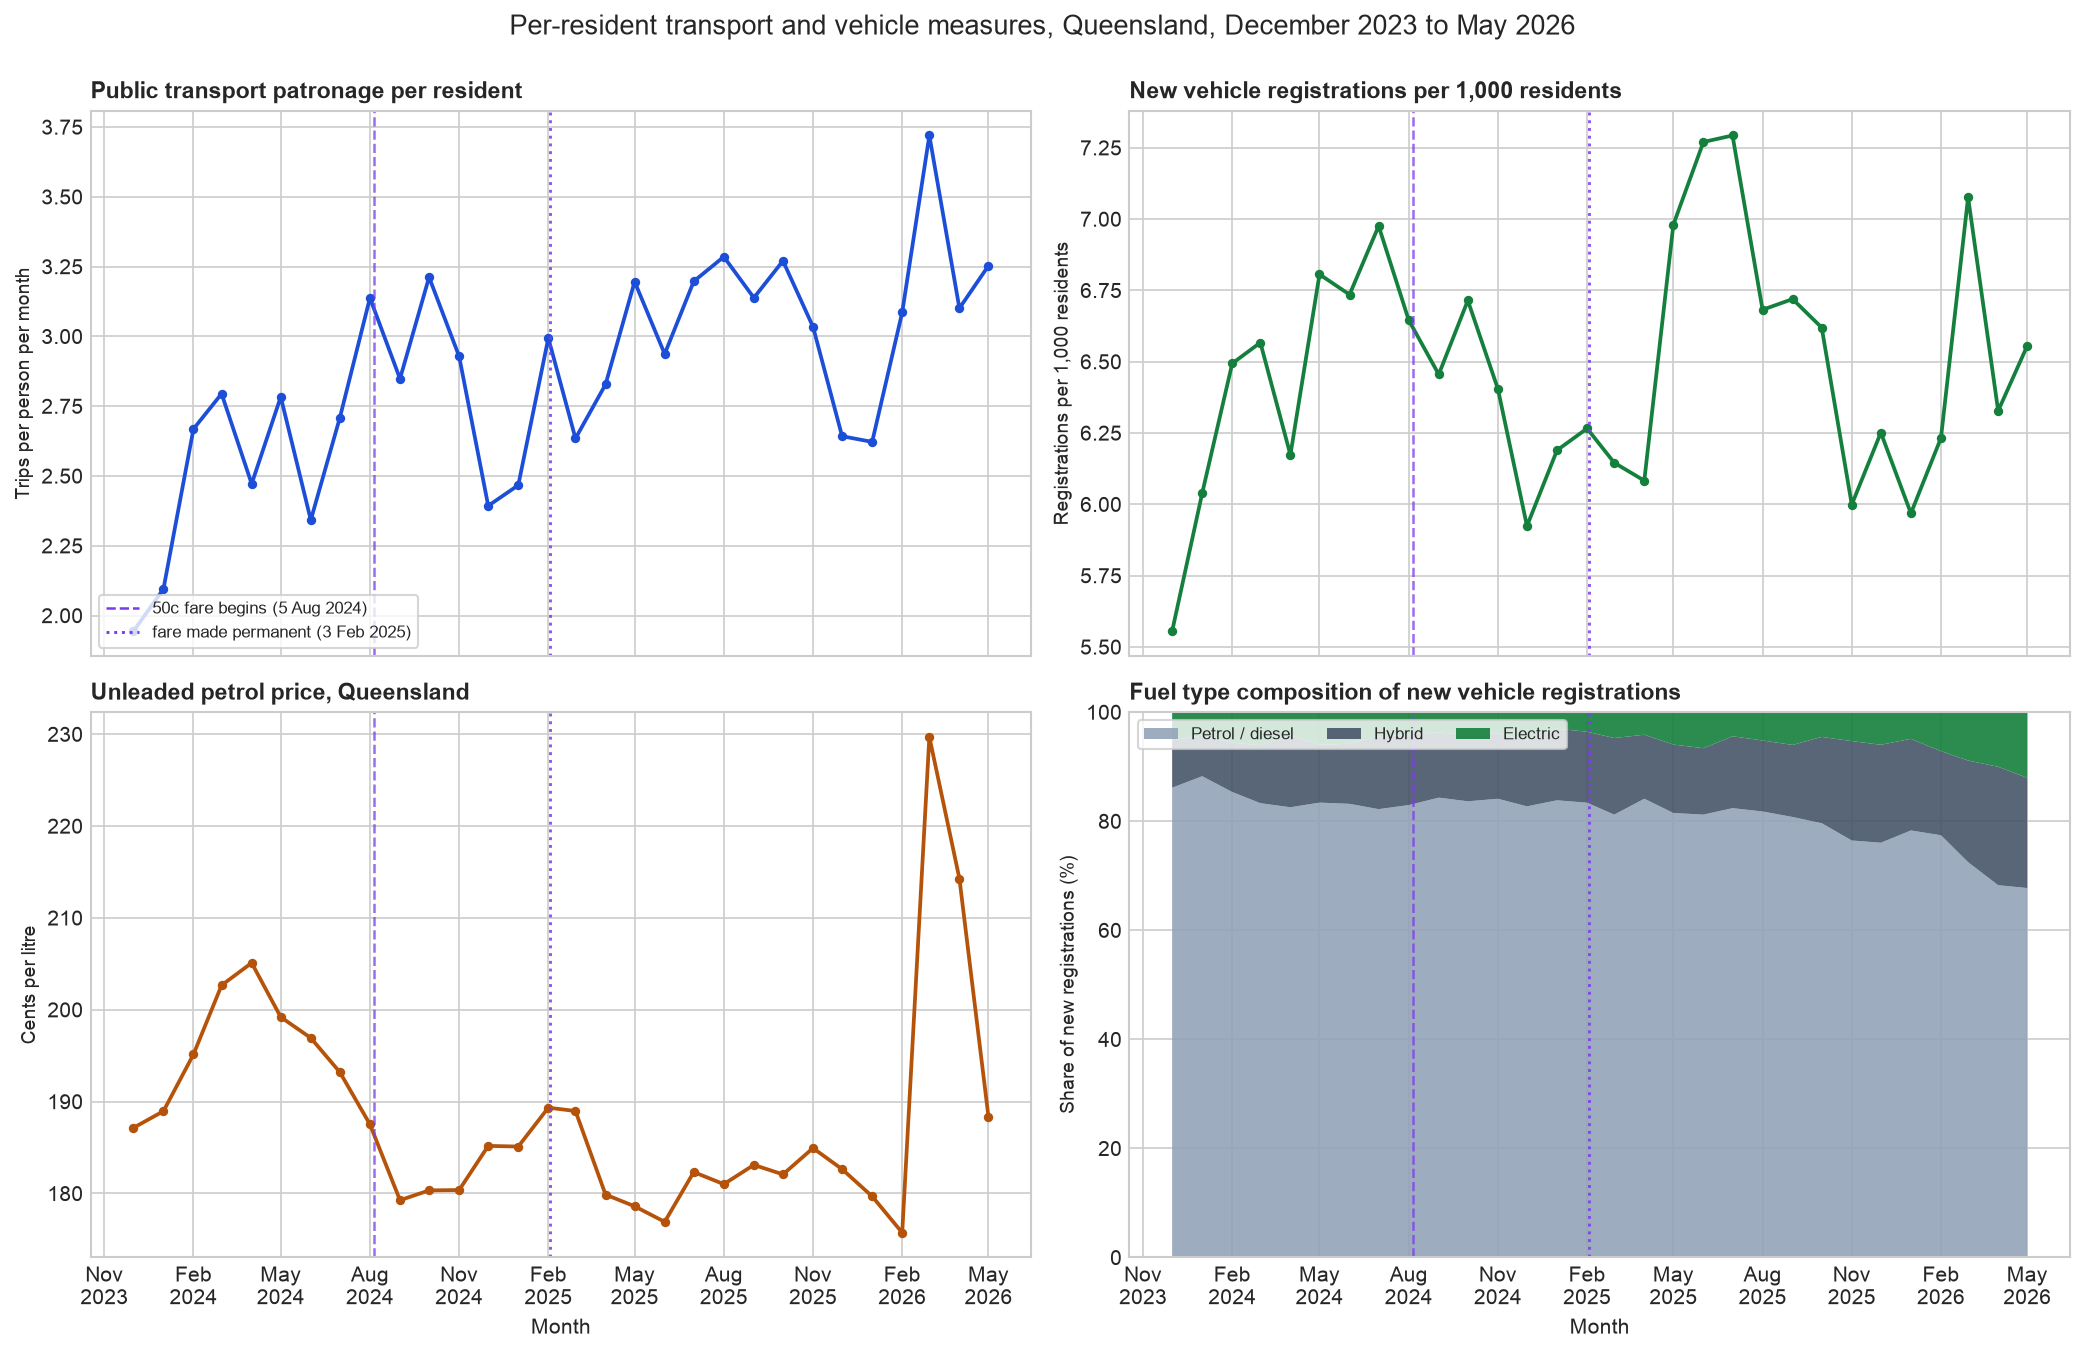

In [23]:
# Raw on the left, per resident on the right, same variable in the same colour,
# so the size of the population adjustment is visible rather than asserted.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
ax = axes.ravel()

# Counts are shown per resident. The fuel price is not a count, so it keeps its
# own units -- there is no defensible way to divide cents per litre by people.
panels = [
    (analysis['trips_per_resident'], 'Public transport patronage per resident',
     'Trips per person per month', C['patronage']),
    (analysis['registrations_per_1000'], 'New vehicle registrations per 1,000 residents',
     'Registrations per 1,000 residents', C['cars']),
    (analysis['ulp_cpl'], 'Unleaded petrol price, Queensland',
     'Cents per litre', C['fuel']),
]
for a, (series, title, ylab, colour) in zip(ax, panels):
    a.plot(series.index, series.values, color=colour, marker='o', ms=3.5, lw=1.8)
    a.set_title(title, loc='left', fontsize=11, fontweight='bold')
    a.set_ylabel(ylab, fontsize=9)
    a.axvline(FARE_TRIAL, **POLICY_KW)
    a.axvline(FARE_PERMANENT, **PERMANENT_KW)

# Fourth panel: what new registrations are made of. Categories must be mutually
# exclusive -- "Petrol And Electric" is a hybrid, and matching naively on
# 'petrol' would count it as both a petrol car and a hybrid. A share is a ratio
# of registrations to registrations, so population cancels and this is the one
# panel that needs no adjustment.
mix = reg_by_fuel.reindex(analysis.index).fillna(0)
CONVENTIONAL = {'petrol', 'diesel', 'gas', 'petrol and gas', 'diesel and gas'}
groups = {
    'Petrol / diesel': [c for c in mix.columns if c.strip().lower() in CONVENTIONAL],
    'Hybrid':          [c for c in mix.columns if 'and electric' in c.lower()],
    'Electric':        [c for c in mix.columns if c.strip().lower() == 'electric'],
}
share = pd.DataFrame({g: mix[cols].sum(axis=1) for g, cols in groups.items()})
share = share.div(share.sum(axis=1), axis=0) * 100

ax[3].stackplot(share.index, [share[g] for g in share.columns], labels=share.columns,
                colors=['#94a3b8', '#475569', C['cars']], alpha=0.9)
ax[3].set_title('Fuel type composition of new vehicle registrations',
                loc='left', fontsize=11, fontweight='bold')
ax[3].set_ylabel('Share of new registrations (%)', fontsize=9)
ax[3].set_ylim(0, 100)
ax[3].legend(loc='upper left', fontsize=8, ncol=3, frameon=True)
ax[3].axvline(FARE_TRIAL, **POLICY_KW)
ax[3].axvline(FARE_PERMANENT, **PERMANENT_KW)

# Label the two policy lines once, in the first panel's legend, rather than
# annotating all four.
axes[0, 0].legend(handles=[
    Line2D([], [], color=C['fare'], ls='--', lw=1.2, label='50c fare begins (5 Aug 2024)'),
    Line2D([], [], color=C['fare'], ls=':', lw=1.4, label='fare made permanent (3 Feb 2025)'),
], loc='lower left', fontsize=8, frameon=True)

for a in axes[-1]:
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    a.set_xlabel('Month')
fig.suptitle('Per-resident transport and vehicle measures, Queensland, December 2023 to May 2026',
             fontsize=13, y=0.997)
plt.tight_layout()
plt.show()

**Reading the shapes.** Counts are per resident throughout, and the shapes are what matter.
Patronage has a clear seasonal sawtooth and a visible step up after August 2024; dividing by
population lowers the line without flattening the step, which is the first sign that the step is
not simply the state growing. Registrations tell a different story, and the adjustment is not the
whole of it: the per-1,000-resident series is far more volatile than patronage, swinging between
roughly 107 and 131 on the index, and drifts up only slowly to end about a fifth above where it
started. Only about a fifth of that rise is population — dividing by residents takes off no more
than that — so car buying per person did increase over the window, just far less than patronage
did. The fuel price wanders in a band around $1.80–1.90/L and then spikes hard in early 2026. The
composition panel is the one that needs no adjustment at all — a share is already a ratio, so
dividing it by population would be counting the denominator twice.

**Two more views of the same window.** Indexing every series to the first month of the window
puts them on one axis, which answers a question four separate y-axes cannot: moved most,
relative to where it started. The heatmap does the opposite, keeping the levels and laying them
out as a month-by-year grid so the summer peaks line up vertically and the year-on-year step
after August 2024 reads across the rows.

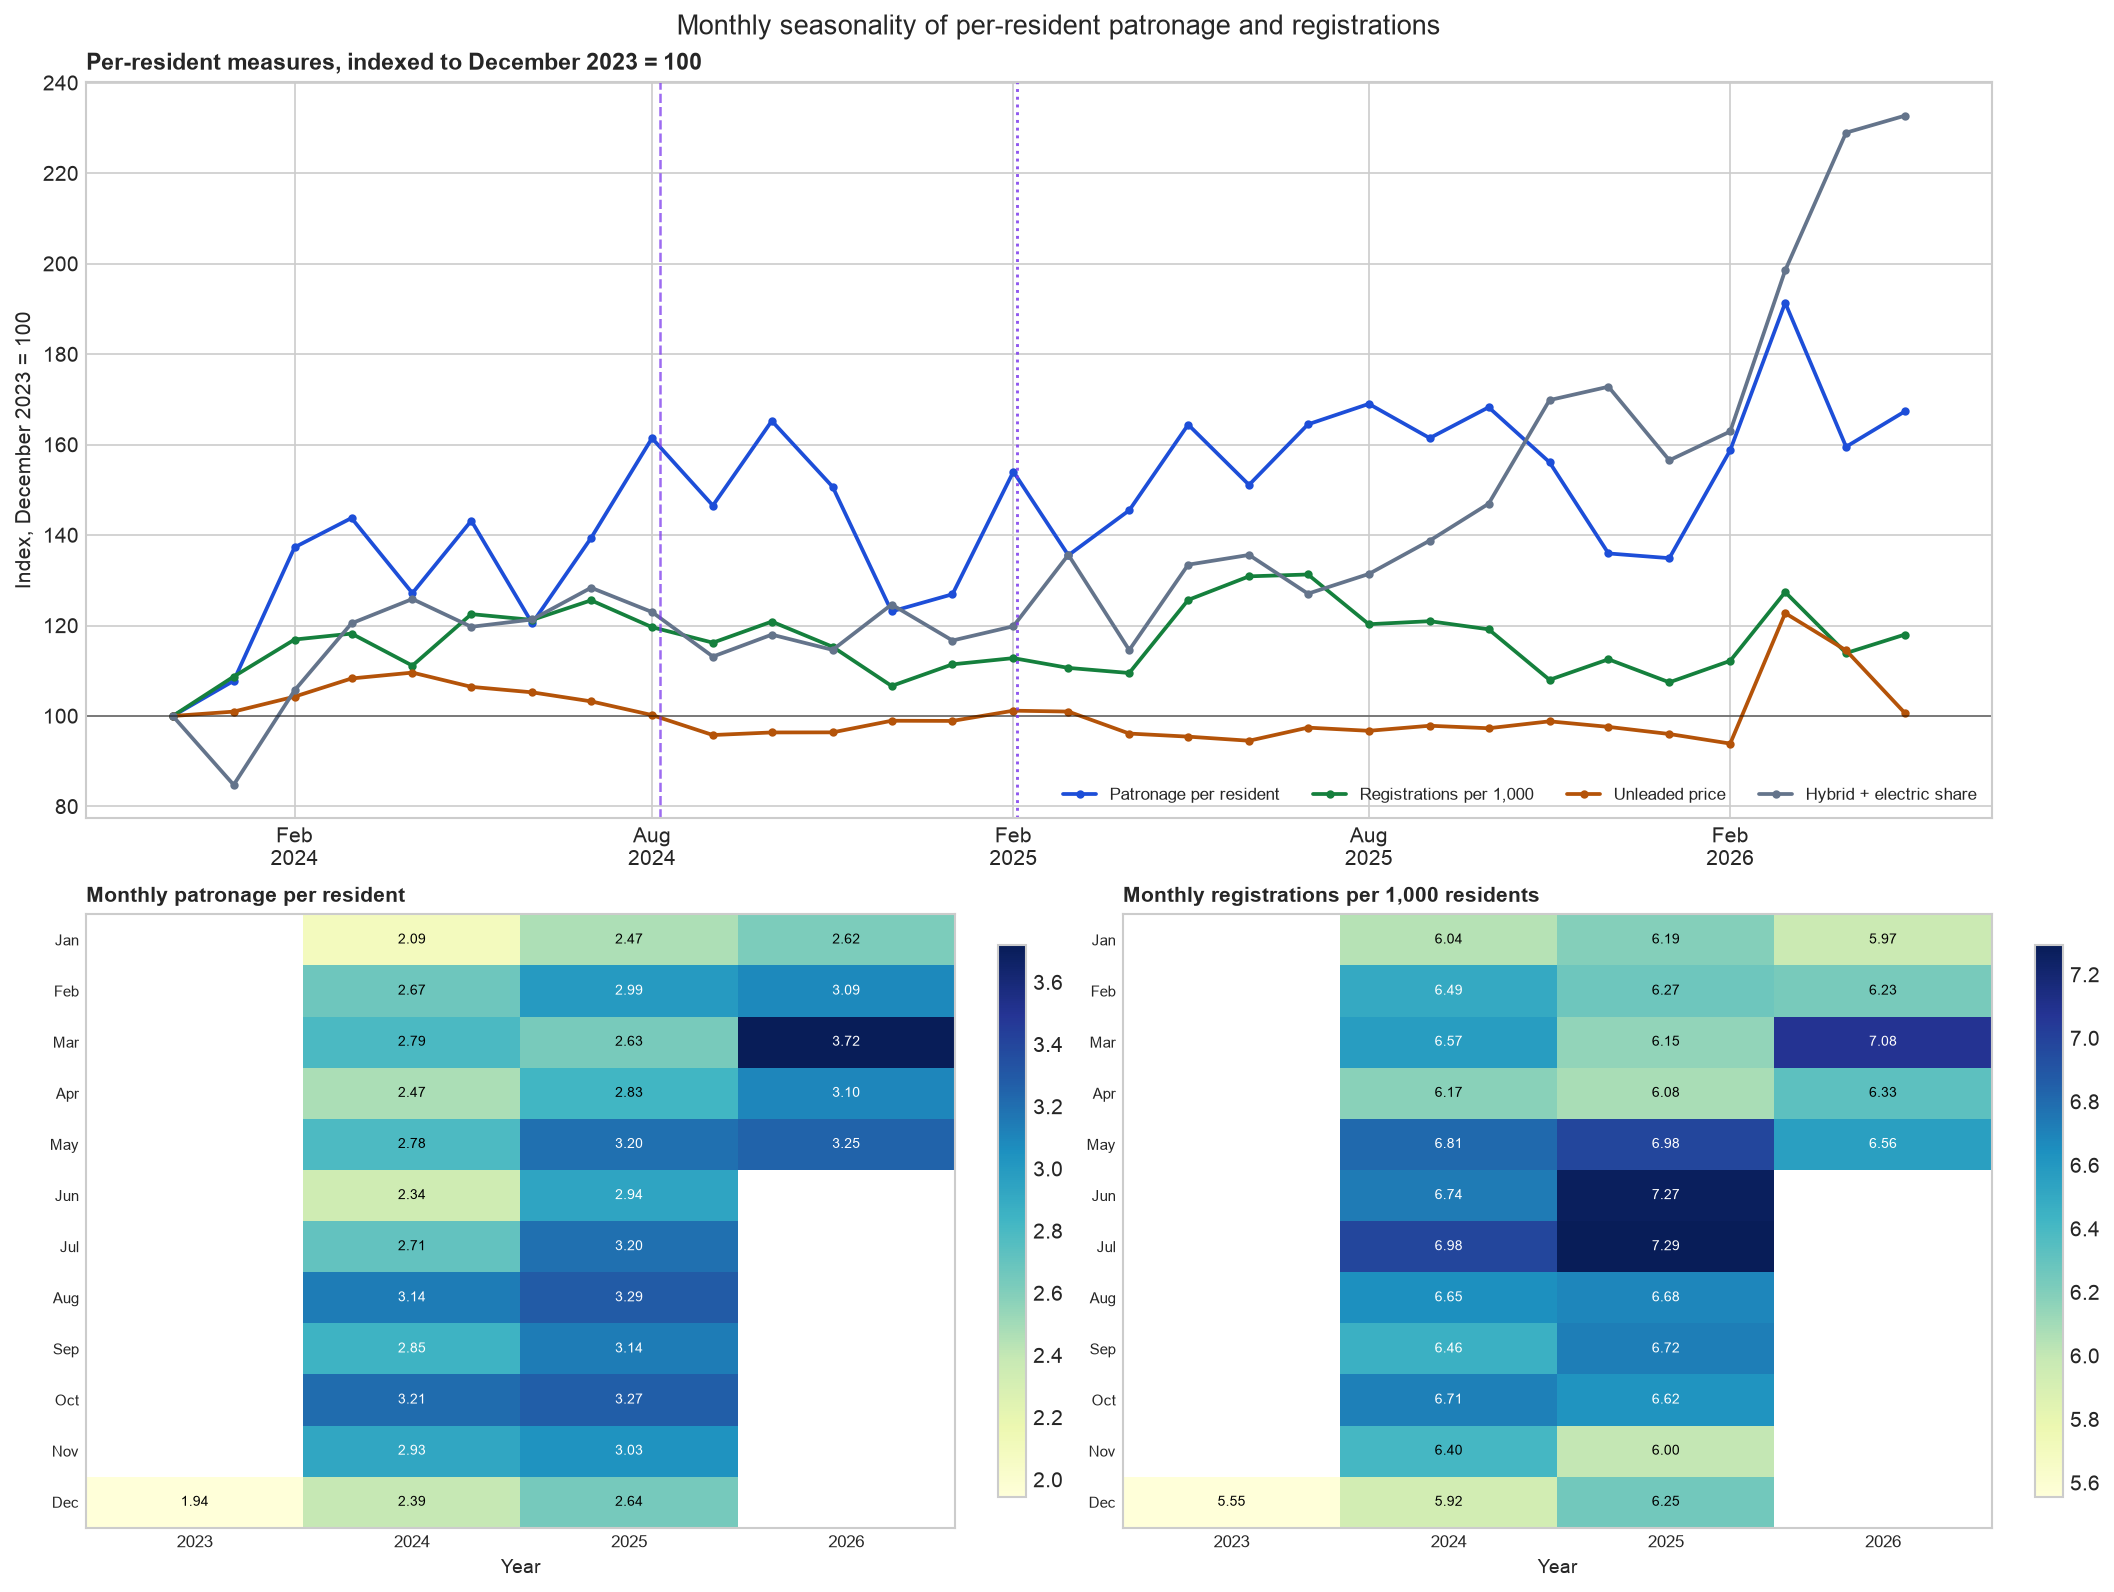

Index at the last month, Dec 2023 = 100:
Hybrid + electric share   232.70
Patronage per resident    167.40
Registrations per 1,000   118.00
Unleaded price            100.60

Queensland population on the same index: 104.4
Every count above has that growth already divided out, so what remains
cannot be explained by the state getting bigger.


In [24]:
# Everything rebased to Dec 2023 = 100. Counts enter per resident, so what is
# left is the movement that population growth does not account for. Population
# itself is printed underneath as the yardstick for how much was removed.
indexed = pd.DataFrame({
    'Patronage per resident': analysis['trips_per_resident'],
    'Registrations per 1,000': analysis['registrations_per_1000'],
    'Unleaded price': analysis['ulp_cpl'],
    'Hybrid + electric share': share['Hybrid'] + share['Electric'],
}).dropna()
indexed = indexed / indexed.iloc[0] * 100

fig = plt.figure(figsize=(14, 10.5), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

ax = fig.add_subplot(gs[0, :])
for col, colour in [('Patronage per resident', C['patronage']),
                    ('Registrations per 1,000', C['cars']),
                    ('Unleaded price', C['fuel']),
                    ('Hybrid + electric share', C['muted'])]:
    ax.plot(indexed.index, indexed[col], color=colour, marker='o', ms=3, lw=1.8, label=col)
ax.axhline(100, color='black', lw=0.8, alpha=0.5)
ax.axvline(FARE_TRIAL, **POLICY_KW)
ax.axvline(FARE_PERMANENT, **PERMANENT_KW)
ax.set_title('Per-resident measures, indexed to December 2023 = 100', loc='left',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Index, December 2023 = 100')
ax.legend(fontsize=8, ncol=4)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))


def month_year(series):
    # Month rows by year columns -- the layout that makes seasonality visible.
    g = series.to_frame('v')
    g.index = g.index.rename(None)   # 'month' would collide with the column below
    g['year'] = g.index.year
    g['month'] = g.index.month
    return g.pivot_table(index='month', columns='year', values='v').reindex(range(1, 13))


# Seasonality of both count series, each per resident. They are in different
# units -- trips against registrations per 1,000 -- so each grid carries its own
# colour scale rather than sharing one that would invite a false comparison.
for k, (series, label, fmt) in enumerate([
        (analysis['trips_per_resident'], 'Monthly patronage per resident', '{:.2f}'),
        (analysis['registrations_per_1000'], 'Monthly registrations per 1,000 residents', '{:.2f}')]):
    grid = month_year(series)
    a = fig.add_subplot(gs[1, k])
    im = a.imshow(grid.values, cmap='YlGnBu', aspect='auto')
    a.set_xticks(range(len(grid.columns)), [str(y) for y in grid.columns], fontsize=8)
    a.set_yticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=7)
    cut = (np.nanmin(grid.values) + np.nanmax(grid.values)) / 2
    for r in range(12):
        for c in range(len(grid.columns)):
            v = grid.values[r, c]
            if not np.isnan(v):
                a.text(c, r, fmt.format(v), ha='center', va='center', fontsize=6.5,
                       color='white' if v > cut else 'black')
    a.set_title(label, loc='left', fontsize=10, fontweight='bold')
    a.set_xlabel('Year', fontsize=9)
    # The whitegrid style draws lines at every tick, which on an imshow land on
    # the centre of each cell and cut it in half.
    a.grid(False)
    fig.colorbar(im, ax=a, shrink=0.9)
fig.suptitle('Monthly seasonality of per-resident patronage and registrations', fontsize=13)
plt.show()

pop_index = 100 * pop_monthly.iloc[-1] / pop_monthly.iloc[0]
print('Index at the last month, Dec 2023 = 100:')
print(indexed.iloc[-1].round(1).sort_values(ascending=False).to_string())
print()
print(f'Queensland population on the same index: {pop_index:.1f}')
print('Every count above has that growth already divided out, so what remains')
print('cannot be explained by the state getting bigger.')

**Reading the picture.** Three series have risen and one has gone nowhere. The hybrid-plus-
electric share more than doubles, from 13.9% of new registrations to 32.3%; trips per resident
end two-thirds above their December 2023 level, at 167 on the index; registrations per 1,000
residents are up by about a fifth, at 118; and the unleaded price ends at 101, close to where it
started, despite swinging widely in between. That divergence is the argument of the whole notebook in
one chart — a series that climbs steadily across three years cannot be responding to a price
that returns to its starting point. Note what the per-resident counts have already removed.
Queensland's population grew by about 4% over the window, so the raw trip and registration
lines would both have been steeper; every count in this figure has that growth divided out
before it is drawn, and what remains cannot be explained by the state getting bigger. The two
heatmaps show what the year-on-year method corrects for: every year peaks in the same months,
so a before-and-after average taken over a mostly-summer pre-window would have compared the
seasons rather than the policy. The second grid is the more sharply seasonal of the two,
because car buying swings harder across the year than public transport use does.

**4.2 The correlation trap.** Every one of these series trends or cycles over 30 months, so a
correlation between **levels** mostly measures the fact that they all exist in the same window.
The honest comparison is between **year-on-year changes**, which removes the shared seasonal
cycle and the common trend.

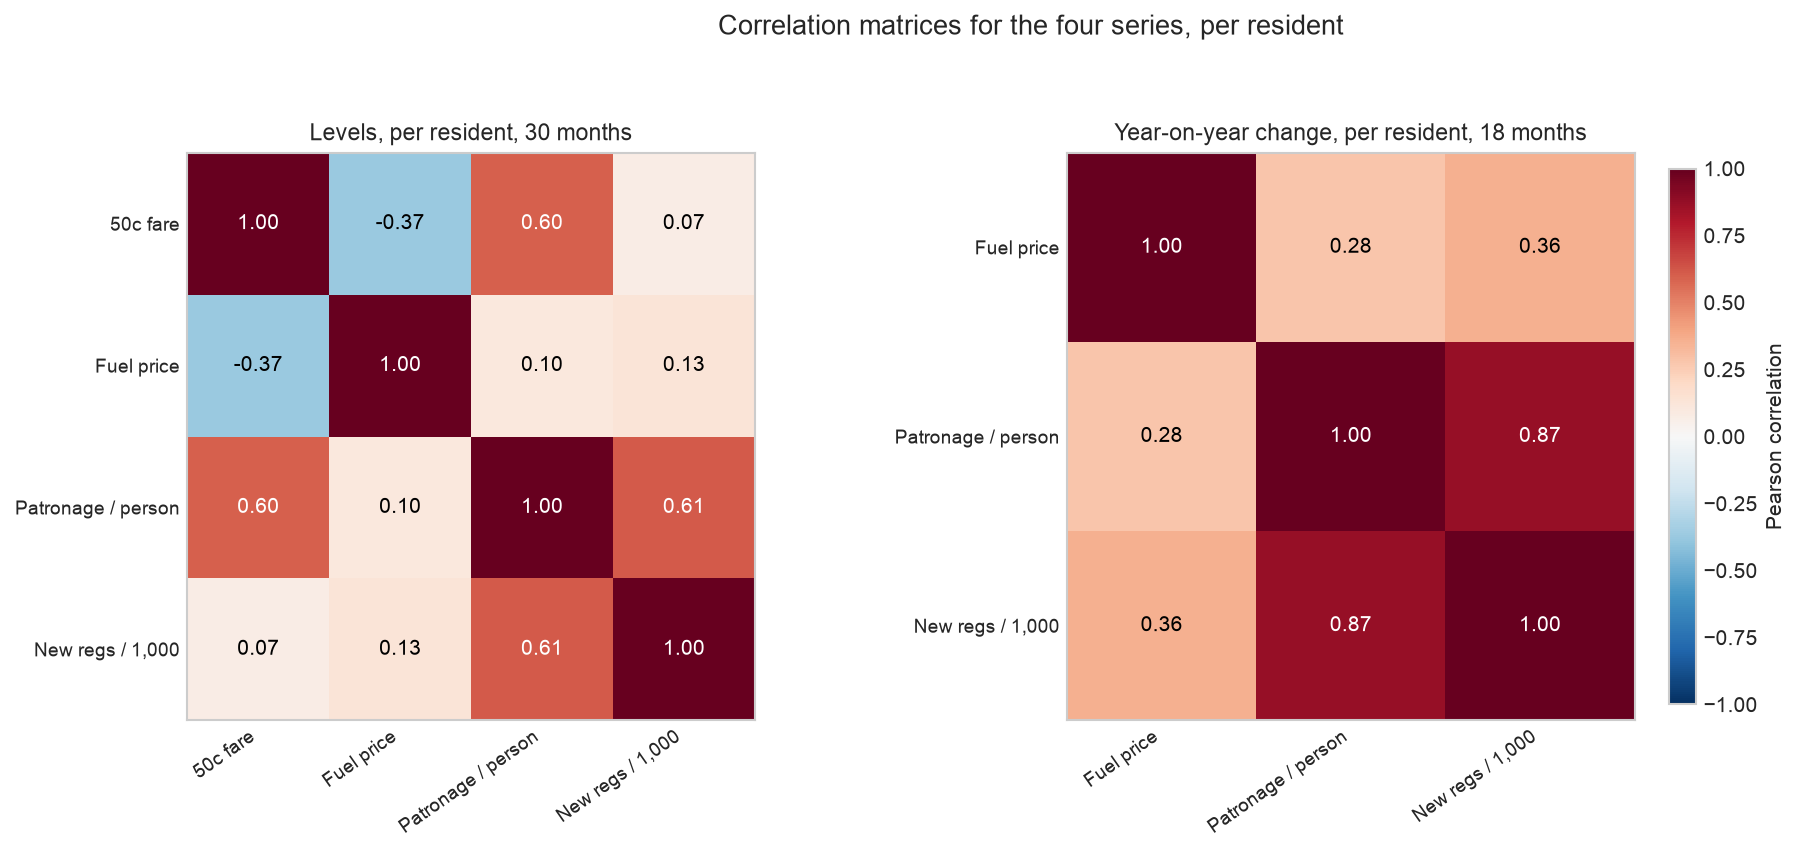

Levels, per resident:
                    50c fare  Fuel price  Patronage / person  New regs / 1,000
50c fare                1.00       -0.37                0.60              0.07
Fuel price             -0.37        1.00                0.10              0.13
Patronage / person      0.60        0.10                1.00              0.61
New regs / 1,000        0.07        0.13                0.61              1.00

Year-on-year %, per resident:
                    Fuel price  Patronage / person  New regs / 1,000
Fuel price                1.00                0.28              0.36
Patronage / person        0.28                1.00              0.87
New regs / 1,000          0.36                0.87              1.00

Strongest year-on-year relationships, per resident:
Patronage / person  ~  New regs / 1,000   0.87
Fuel price  ~  New regs / 1,000           0.36
Fuel price  ~  Patronage / person         0.28


In [25]:
# Counts per resident. The fuel price and the fare dummy are not counts, so they
# stay in their own units -- dividing a price, or a 0/1 flag, by population would
# be meaningless.
HEAD = {'fare_50c': '50c fare', 'ulp_cpl': 'Fuel price',
        'trips_per_resident': 'Patronage / person',
        'registrations_per_1000': 'New regs / 1,000'}

lev_head = analysis[list(HEAD)].rename(columns=HEAD)

# Year-on-year change: same month, one year apart. Costs 12 observations, which
# has a consequence worth noting -- every surviving month is already post-policy,
# so the fare dummy is constant here and drops out. It cannot be correlated with
# anything in this frame; that is a limit of the design, not a missing number.
yoy_head = (analysis[['ulp_cpl', 'trips_per_resident', 'registrations_per_1000']]
            .pct_change(12, fill_method=None) * 100).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
fig.subplots_adjust(wspace=0.55)
for ax, m, title in [
        (axes[0], lev_head.corr(), f'Levels, per resident, {len(lev_head)} months'),
        (axes[1], yoy_head.rename(columns=HEAD).corr(),
         f'Year-on-year change, per resident, {len(yoy_head)} months')]:
    im = ax.imshow(m.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(m)), m.columns, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(m)), m.index, fontsize=9)
    ax.set_title(title, fontsize=11)
    for a in range(len(m)):
        for b in range(len(m)):
            v = m.values[a, b]
            ax.text(b, a, f'{v:.2f}', ha='center', va='center', fontsize=10,
                    color='white' if abs(v) > 0.55 else 'black')
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02, label='Pearson correlation')
fig.suptitle('Correlation matrices for the four series, per resident', fontsize=13)
plt.show()

print('Levels, per resident:')
print(lev_head.corr().round(2).to_string())
print()
print('Year-on-year %, per resident:')
corr_yoy_head = yoy_head.rename(columns=HEAD).corr()
print(corr_yoy_head.round(2).to_string())
print()
print('Strongest year-on-year relationships, per resident:')
pairs = (corr_yoy_head.where(~np.eye(len(corr_yoy_head), dtype=bool))
         .stack().dropna().sort_values(ascending=False))
seen, out = set(), []
for (a, b), v in pairs.items():
    key = frozenset((a, b))
    if key not in seen:
        seen.add(key)
        out.append((f'{a}  ~  {b}', v))
print(pd.Series(dict(out)).head(5).round(2).to_string())

**Read the numbers before the colour.** Everything here is counted per resident. The raw
figures are quoted rather than drawn, because they are the comparison the adjustment has to
answer for. On raw levels the picture is mixed rather than uniformly strong: patronage moves
with new registrations at 0.69 and with the fare dummy at 0.63, while the fuel price barely
registers against either (0.10 against patronage, 0.11 against registrations). Recounting per
resident lowers those exactly where it should. The fare dummy against registrations falls from
0.21 to 0.07, and patronage against registrations from 0.69 to 0.61, because part of what those
pairs shared was simply a state that kept growing. The fare dummy against patronage barely moves
at all, 0.63 to 0.60, which is informative in its own right: whatever that correlation is
measuring, it is not mainly population.

The more interesting result is where the adjustment does nothing. The year-on-year matrix is
essentially the same whichever way the counts are expressed — 0.87 for patronage against
registrations on raw trips and 0.87 per resident, 0.35 against 0.36 for fuel — because comparing
the same month a year earlier has already removed the population trend that the denominator would
remove. The two corrections are largely redundant, and noticing that is useful: it says the
year-on-year frame was the population-clean comparison all along, and the per-resident counts
are a check on it rather than a replacement.

Note finally what is missing from the year-on-year matrix. The fare dummy appears in the levels
panel but cannot appear here, because a frame reaching back twelve months survives only in months
that are already post-policy, where the dummy is constant. That is a limit of the design, not a
missing number, and it is why the fare's effect has to be read off the before/after comparison in
§4.3 rather than off a correlation.

**4.3 RQ2 — did the 50-cent fare lift patronage?** With only eight months before the change, a
simple before/after average would be swamped by seasonality — the pre-window is almost entirely
summer. So the comparison is **same month, one year earlier**: March 2025 against March 2024,
and so on. That removes the seasonal shape and leaves the change over the year.

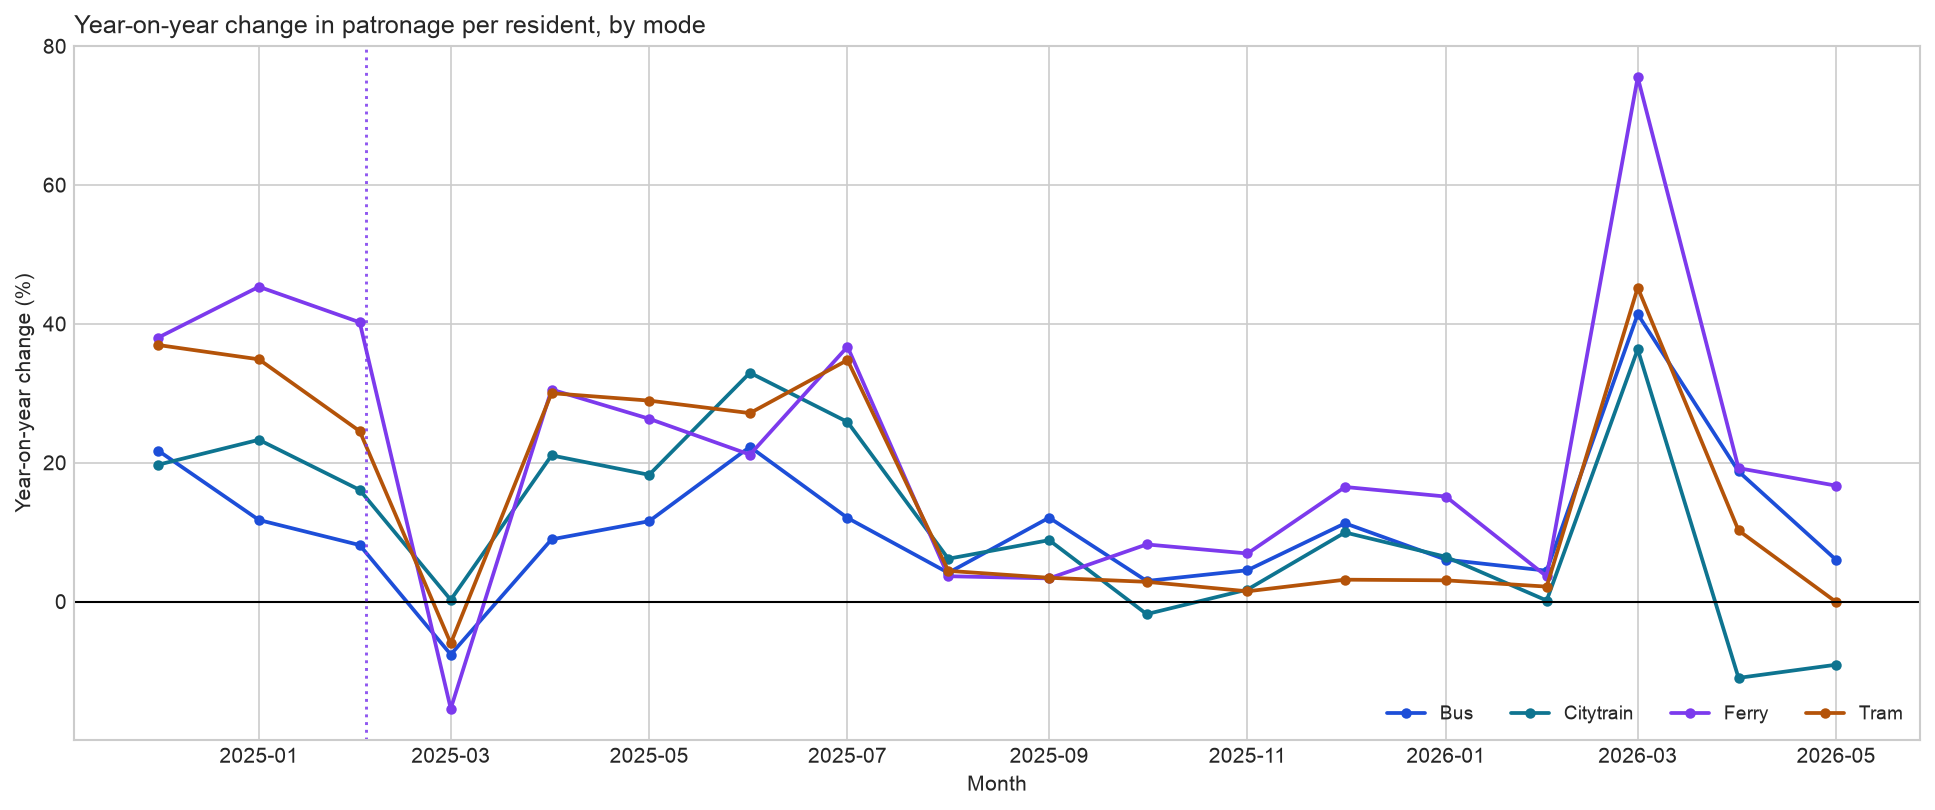

Mean year-on-year change in trips per resident after the fare cut:
mode
Ferry       21.80
Tram        16.00
Citytrain   11.40
Bus         11.10

The same figures on raw trips, for comparison:
mode
Ferry       23.90
Tram        18.00
Citytrain   13.30
Bus         13.10

Population growth lifts every mode by about 2.0 points, which is the part of the raw growth no fare bought.

Two periods, to test whether the increase persisted (per resident):
           first policy year (Sep24-Aug25)  since Sep 2025
mode                                                      
Bus                                  10.30           11.90
Citytrain                            18.20            4.60
Ferry                                25.20           18.30
Tram                                 24.00            7.90


In [26]:
yoy_mode = trips_by_mode.pct_change(12, fill_method=None) * 100
# Start from the first fully-treated month, so the transition month is not counted.
yoy_mode = yoy_mode.loc[yoy_mode.index >= FARE_FIRST_FULL_MONTH].dropna(how='all')

# The same growth rates per resident. A mode that grows 13% while the population
# it draws from grows 2% has grown 11% in the only sense a passenger would
# recognise.
pop_aligned = pop_monthly.reindex(trips_by_mode.index)
yoy_mode_rate = (trips_by_mode.div(pop_aligned, axis=0)
                 .pct_change(12, fill_method=None) * 100)
yoy_mode_rate = (yoy_mode_rate.loc[yoy_mode_rate.index >= FARE_FIRST_FULL_MONTH]
                 .dropna(how='all'))

mode_colours = {'Bus': '#1d4ed8', 'Citytrain': '#0e7490', 'Ferry': '#7c3aed', 'Tram': '#b45309'}
fig, ax = plt.subplots(figsize=(13, 5.5))
for mode in yoy_mode_rate.columns:
    ax.plot(yoy_mode_rate.index, yoy_mode_rate[mode], marker='o', ms=4, lw=1.8,
            color=mode_colours.get(mode, C['muted']), label=mode)
ax.axhline(0, color='black', lw=1)
ax.axvline(FARE_PERMANENT, **PERMANENT_KW)
ax.set_title('Year-on-year change in patronage per resident, by mode',
             loc='left')
ax.set_ylabel('Year-on-year change (%)')
ax.set_xlabel('Month')
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

print('Mean year-on-year change in trips per resident after the fare cut:')
print(yoy_mode_rate.mean().sort_values(ascending=False).round(1).to_string())
print()
print('The same figures on raw trips, for comparison:')
print(yoy_mode.mean().sort_values(ascending=False).round(1).to_string())
print()
print(f'Population growth lifts every mode by about '
      f'{(yoy_mode.mean() - yoy_mode_rate.mean()).mean():.1f} points, which is the part '
      f'of the raw growth no fare bought.')
print()
print('Two periods, to test whether the increase persisted (per resident):')
first_year = yoy_mode_rate.loc[:'2025-08-31'].mean()
second_year = yoy_mode_rate.loc['2025-09-01':].mean()
print(pd.DataFrame({'first policy year (Sep24-Aug25)': first_year,
                    'since Sep 2025': second_year}).round(1).to_string())

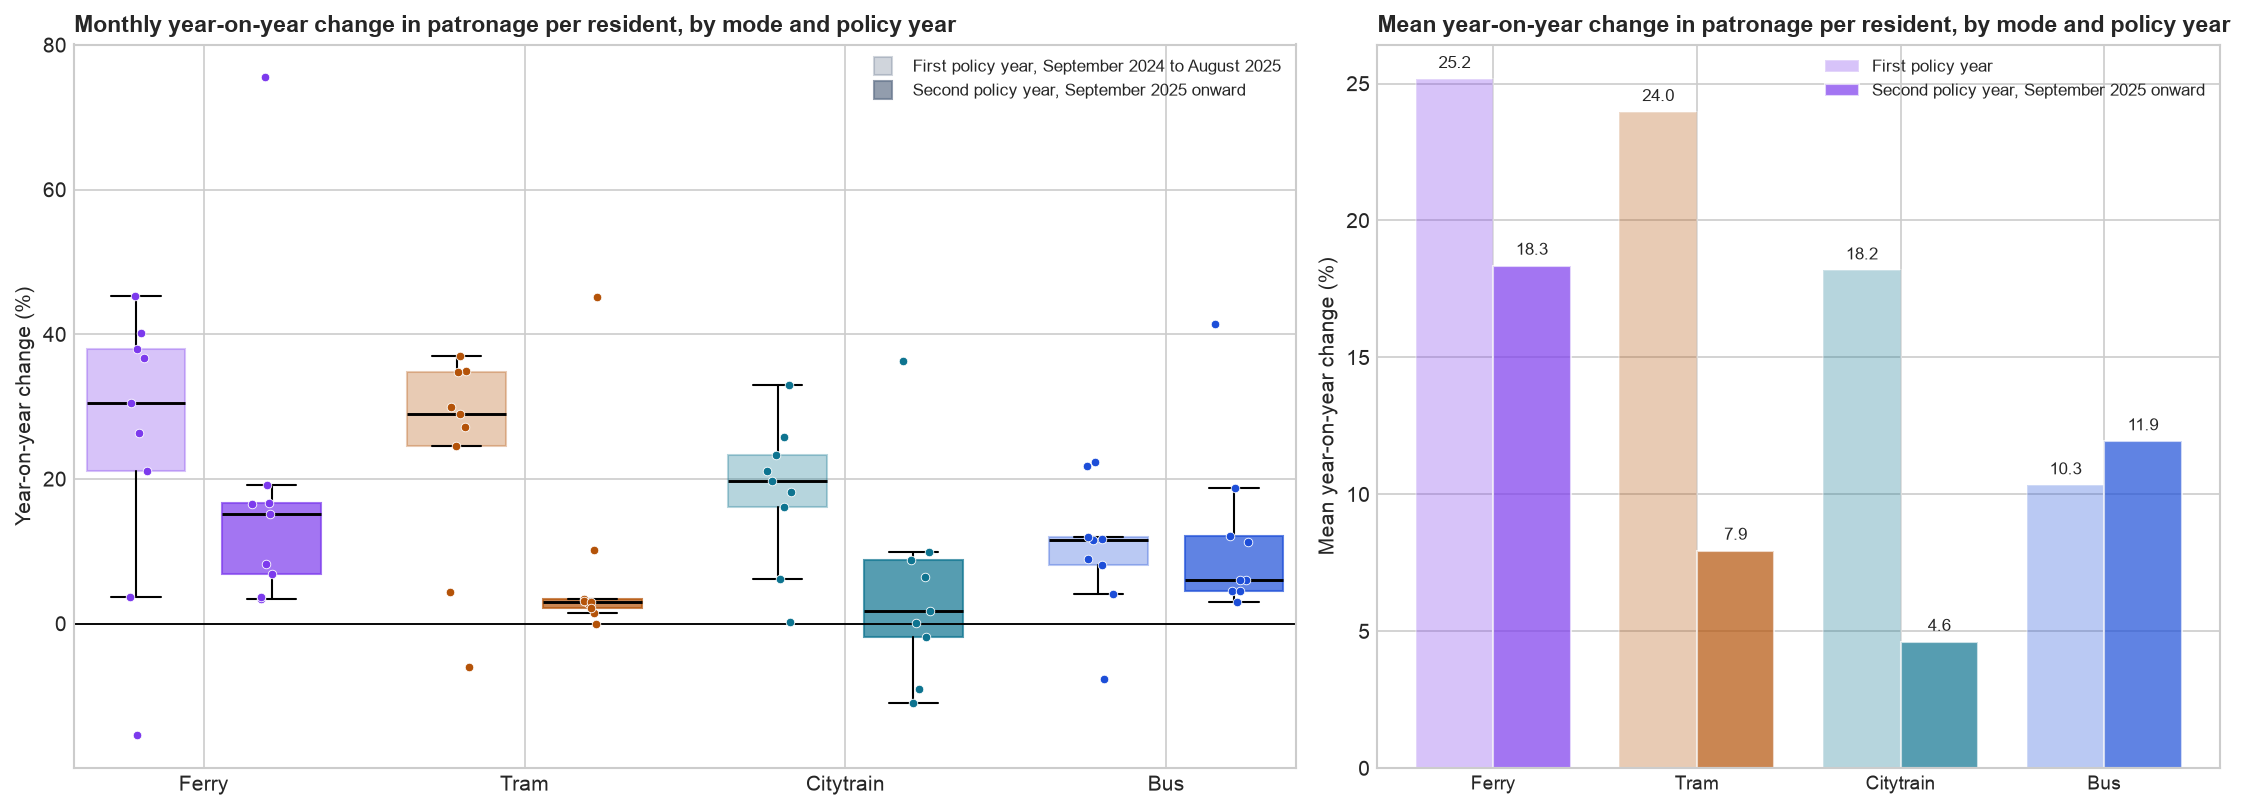

In [27]:
# The same two periods as the table above, drawn. With only 12 and 9 monthly
# observations a mean on its own hides how variable the months are, so every box
# is overlaid with its own points rather than standing alone.
mode_order = yoy_mode_rate.mean().sort_values(ascending=False).index.tolist()
mode_colours = {'Bus': '#1d4ed8', 'Citytrain': '#0e7490', 'Ferry': '#7c3aed', 'Tram': '#b45309'}
rate_parts = (yoy_mode_rate.loc[:'2025-08-31'], yoy_mode_rate.loc['2025-09-01':])
rng = np.random.default_rng(0)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 5.5),
                              gridspec_kw={'width_ratios': [1.45, 1]})
ticks, labels = [], []
for i, mode in enumerate(mode_order):
    colour = mode_colours.get(mode, C['muted'])
    for j, part in enumerate(rate_parts):
        pos = i * 2.6 + j * 1.1 + 1
        pts = part[mode].dropna()
        bp = ax.boxplot([pts], positions=[pos], widths=0.8, patch_artist=True,
                        showfliers=False, medianprops=dict(color='black', lw=1.4))
        bp['boxes'][0].set(facecolor=colour, edgecolor=colour, alpha=0.30 if j == 0 else 0.70)
        ax.scatter(rng.normal(pos, 0.07, len(pts)), pts, s=17, color=colour,
                   edgecolor='white', linewidth=0.4, zorder=3)
    ticks.append(i * 2.6 + 1.55)
    labels.append(mode)
ax.axhline(0, color='black', lw=0.9)
ax.set_xticks(ticks, labels)
ax.set_ylabel('Year-on-year change (%)')
ax.set_title('Monthly year-on-year change in patronage per resident, by mode and policy year', loc='left',
             fontsize=11, fontweight='bold')
ax.legend(handles=[
    Line2D([], [], marker='s', ls='', ms=9, mfc=C['muted'], mec=C['muted'], alpha=0.30,
           label='First policy year, September 2024 to August 2025'),
    Line2D([], [], marker='s', ls='', ms=9, mfc=C['muted'], mec=C['muted'], alpha=0.70,
           label='Second policy year, September 2025 onward'),
], fontsize=8, loc='upper right')

periods = pd.DataFrame({'first': rate_parts[0].mean(),
                        'second': rate_parts[1].mean()}).loc[mode_order]
x = np.arange(len(mode_order))
w = 0.38
colours = [mode_colours.get(m, C['muted']) for m in mode_order]
ax2.bar(x - w / 2, periods['first'], w, color=colours, alpha=0.30, edgecolor='white',
        label='First policy year')
ax2.bar(x + w / 2, periods['second'], w, color=colours, alpha=0.70, edgecolor='white',
        label='Second policy year, September 2025 onward')
for xi, (a, b) in enumerate(zip(periods['first'], periods['second'])):
    ax2.text(xi - w / 2, a + 0.4, f'{a:.1f}', ha='center', fontsize=8)
    ax2.text(xi + w / 2, b + 0.4, f'{b:.1f}', ha='center', fontsize=8)
ax2.axhline(0, color='black', lw=0.9)
ax2.set_xticks(x, mode_order, fontsize=9)
ax2.set_ylabel('Mean year-on-year change (%)')
ax2.set_title('Mean year-on-year change in patronage per resident, by mode and policy year', loc='left', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Reading the persistence.** Bus is the only mode whose second period is at least as strong as
its first, and even there the two means sit close together. Ferry keeps a large gain but gives
back roughly a quarter of it. Citytrain and Tram are the clear decay cases: both post first-year
means above 18% and fall back to single digits afterwards, which is more consistent with a
novelty response than with a durable change in how people commute. The spread matters as much as
the means — where the monthly points scatter widely, any single month would tell you very little,
which is why the points are drawn rather than hidden behind the box.

These are per-resident figures, and that is what makes the comparison honest rather than
flattering. On raw trips the same numbers run about two points higher across the board, which is
population growth being credited to the fare. Subtracting it does not reorder the modes, but it
does sharpen the decay, because taking the same constant off both years widens the ratio between
them: Citytrain's fall from 18.2% to 4.6% is a steeper collapse than the raw 20.3% to 6.3%
suggested. Bus is the one mode still above zero a year later on either reading.

**Adjusting for population.** Queensland added residents throughout this window, and more
residents means more trips even if not one person changes their behaviour. Raw patronage growth
therefore hands the fare credit for something demography did. The honest comparison puts three
things side by side: the change in trips, the change in population, and the change in trips
*per resident* — which is the part a fare actually has to explain.

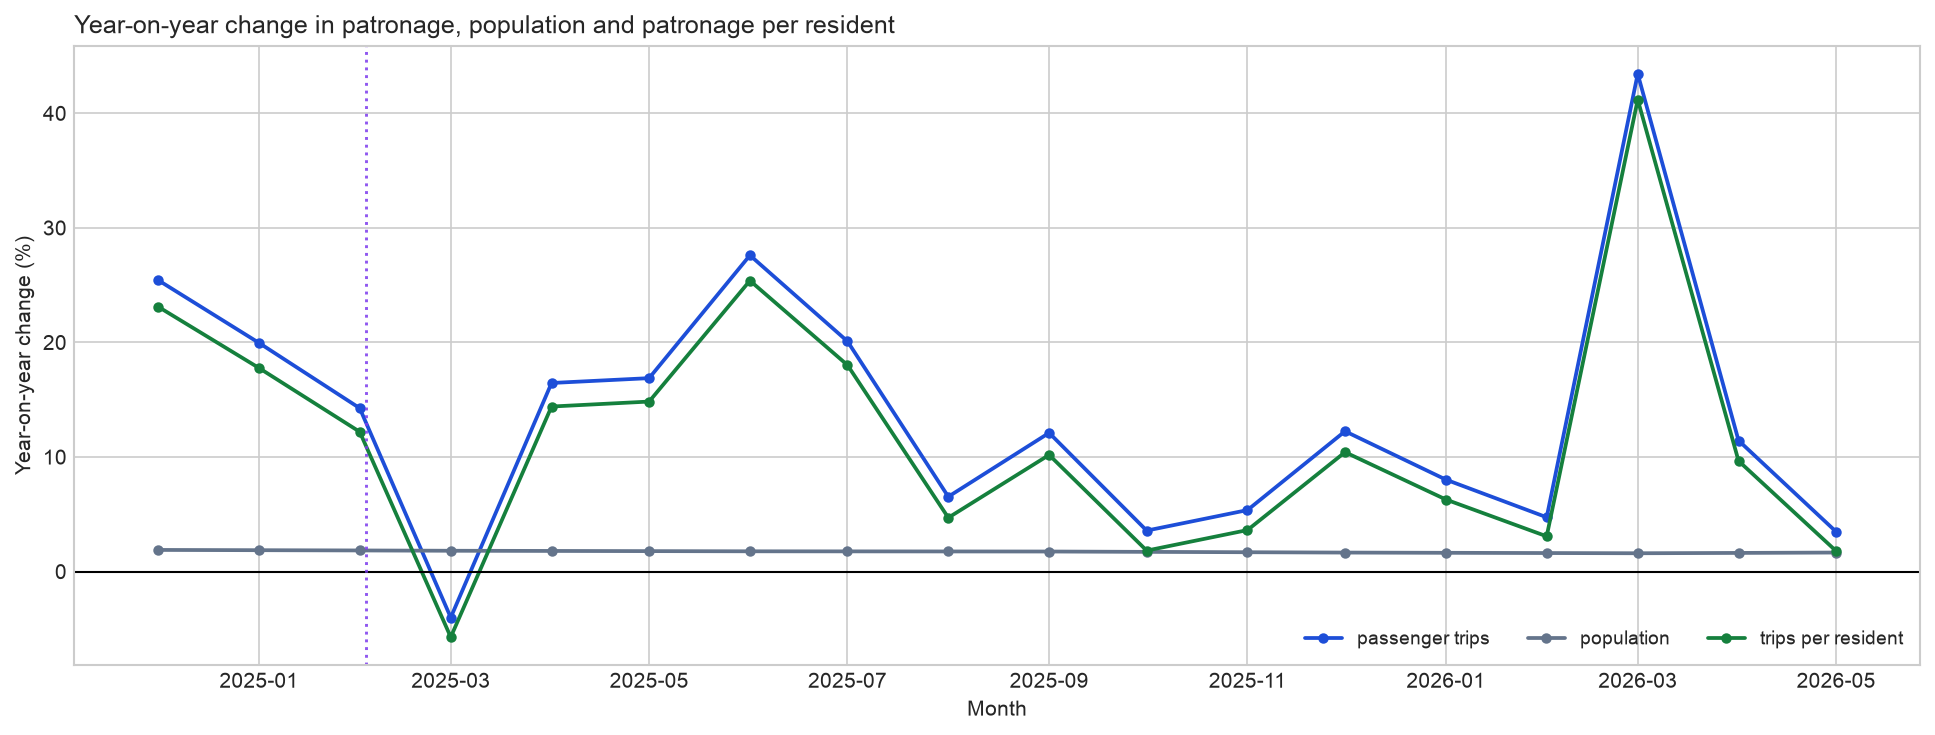

Mean year-on-year change after the fare cut, all modes together:
passenger trips      13.80
population            1.70
trips per resident   11.80

Population growth accounts for 1.7 of the 13.8 percentage-point rise in trips, about 13% of it.
The remaining 11.8% is the part the fare would have to explain.


In [28]:
# Same-month-year-earlier change, for the three quantities. Population is the
# denominator, so a year-on-year population change of +1.7% mechanically lifts
# raw patronage by about that much without anyone travelling more.
yoy_trips_all = trips_total.pct_change(12, fill_method=None) * 100
yoy_pop_all = pop_monthly.pct_change(12, fill_method=None) * 100
yoy_rate_all = trips_per_resident.pct_change(12, fill_method=None) * 100

decomp = pd.DataFrame({
    'passenger trips': yoy_trips_all,
    'population': yoy_pop_all,
    'trips per resident': yoy_rate_all,
}).dropna()
after = decomp.loc[FARE_FIRST_FULL_MONTH:]

fig, ax = plt.subplots(figsize=(13, 5))
for col, colour in [('passenger trips', C['patronage']), ('population', C['muted']),
                    ('trips per resident', C['cars'])]:
    ax.plot(after.index, after[col], marker='o', ms=4, lw=1.8, color=colour, label=col)
ax.axhline(0, color='black', lw=1)
ax.axvline(FARE_PERMANENT, **PERMANENT_KW)
ax.set_ylabel('Year-on-year change (%)')
ax.set_xlabel('Month')
ax.set_title('Year-on-year change in patronage, population and patronage per resident', loc='left')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

print('Mean year-on-year change after the fare cut, all modes together:')
print(after.mean().round(1).to_string())
print()
print(f'Population growth accounts for {after["population"].mean():.1f} of the '
      f'{after["passenger trips"].mean():.1f} percentage-point rise in trips, '
      f'about {100 * after["population"].mean() / after["passenger trips"].mean():.0f}% of it.')
print(f'The remaining {after["trips per resident"].mean():.1f}% is the part the fare would '
      f'have to explain.')

**What to look for.** If the fare cut lifted patronage, points should sit consistently above
zero after August 2024 and every mode should move the same way — a fare cut applies to all four
at once, so a mode that does *not* respond is informative. Two traps are visible in this chart.
The March 2025 dip across Ferry and Bus lines up with **Cyclone Alfred**, which shut down
Southeast Queensland services, and that matters twice over because the *next* March is compared
against it — the huge March 2026 spike is largely a depressed-base artefact, not a sudden surge
in travel. Separately, the early-2026 fuel spike lands in the same period as the highest
patronage readings, so the two levers are partly confounded at the end of the window.

To see the fare effect cleanly, read the right-hand half of the chart. From September 2025 the
comparison is policy-year against policy-year, so the lines show organic growth with no fare step
in the base: Bus holds up at about +11% per resident, and the other modes settle back after their
first-year jump. Every rate here is per resident, so the two points or so by which each mode sits
below its raw counterpart is population growth, and not the fare.

In [29]:
# The naive pre/post gap, shown only to demonstrate how misleading it is.
# The transition month is excluded from both sides.
mode_change = pd.DataFrame({
    'mean pre (Dec23-Jul24)': pre_m[trips_by_mode.columns].mean(),
    'mean post (Sep24-May26)': post_m[trips_by_mode.columns].mean(),
})
mode_change['change (%)'] = (mode_change.iloc[:, 1] / mode_change.iloc[:, 0] - 1) * 100
print(mode_change.round(0).to_string())
print()
print('But this gap is NOT a fare effect: the pre-window is Dec-Jul only, so it compares')
print('part of one summer with a full 21-month period. The year-on-year chart above is')
print('the honest version.')

           mean pre (Dec23-Jul24)  mean post (Sep24-May26)  change (%)
Bus                  8,709,279.00            10,495,876.00       21.00
Citytrain            3,644,357.00             4,584,693.00       26.00
Ferry                  479,126.00               672,766.00       40.00
Tram                   914,353.00             1,226,753.00       34.00

But this gap is NOT a fare effect: the pre-window is Dec-Jul only, so it compares
part of one summer with a full 21-month period. The year-on-year chart above is
the honest version.


**4.4 RQ3 and RQ4 — does the fuel price move cars?** Two different things get called "cars on
the road", and they behave very differently. **Flow** is new registrations each month, which is
a purchase decision and so can respond within a quarter. **Stock** is the total registered
fleet, which moves on the scale of years because it accumulates every past purchase less
scrappage — a fuel price spike cannot move it much in 30 months. The stock figures come from
BITRE at 31 January each year, so there are only three observations.

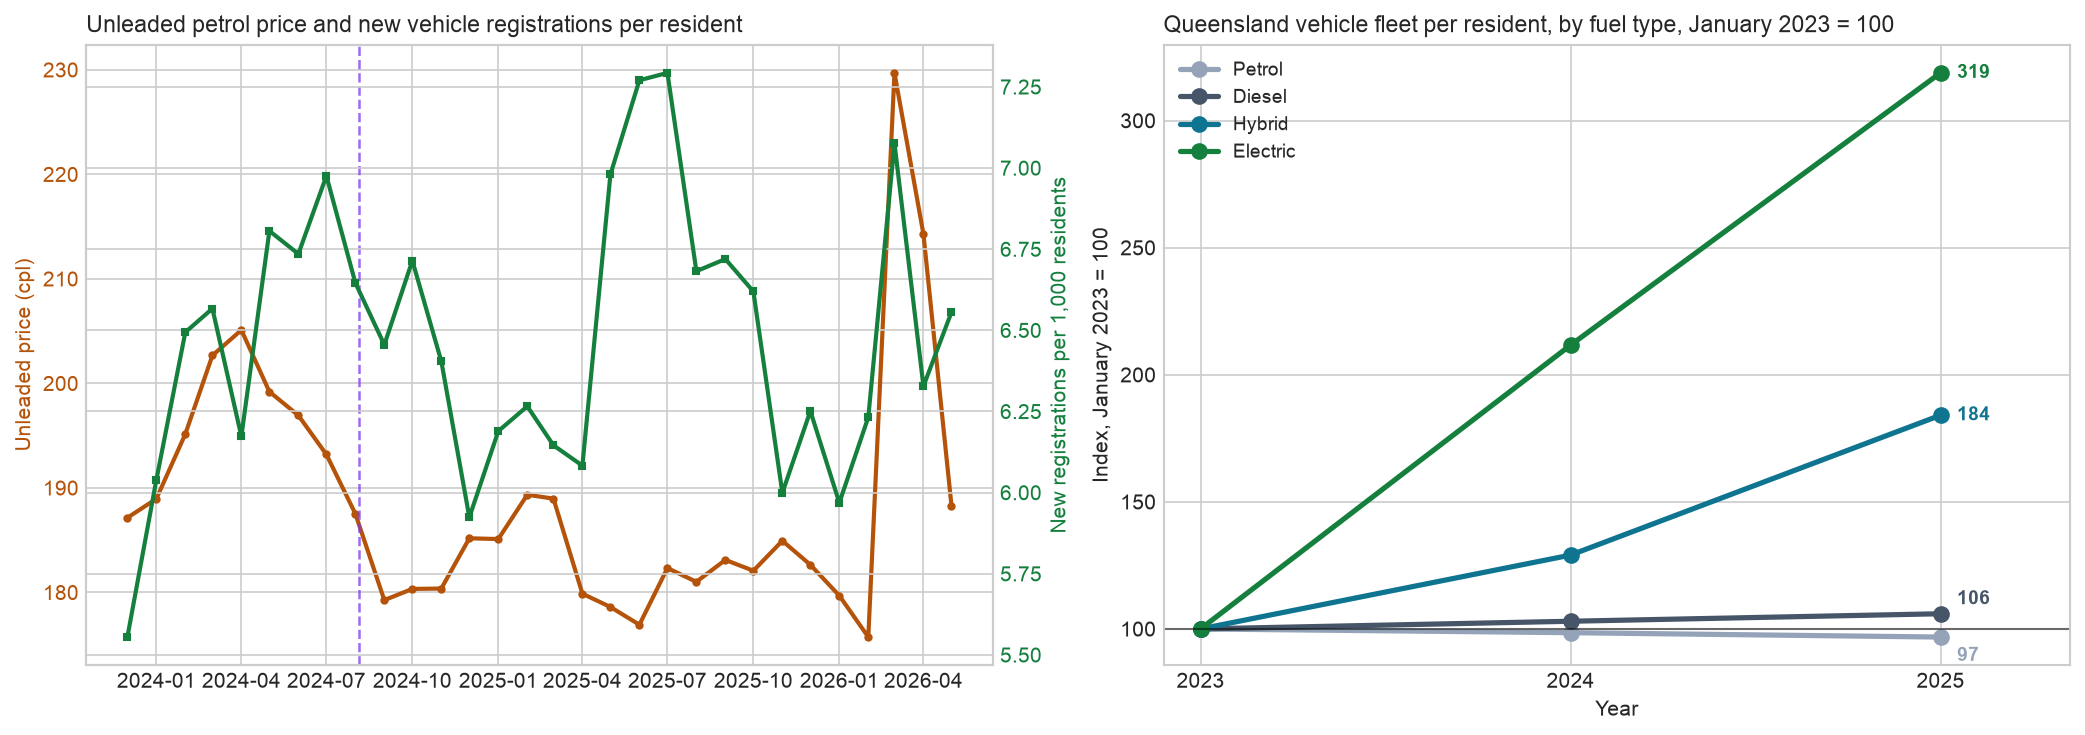

Queensland registered vehicles by fuel type (counts are the source figures):
           Jan 2023  Jan 2025  change (%)  per resident (%)
electric      16715     55661      233.00            218.80
hybrid        72461    139333       92.30             84.10
diesel      1480352   1638716       10.70              6.00
petrol      3008713   3042238        1.10             -3.20
other          3965      3289      -17.00            -20.60
dual_fuel     16420     13227      -19.40            -22.90


In [30]:
bitre_stock = pd.DataFrame({
    'year':      [2023, 2024, 2025],
    'petrol':    [3_008_713, 3_039_720, 3_042_238],
    'diesel':    [1_480_352, 1_563_982, 1_638_716],
    'dual_fuel': [   16_420,    14_800,    13_227],
    'hybrid':    [   72_461,    95_896,   139_333],
    'electric':  [   16_715,    36_280,    55_661],
    'other':     [    3_965,     3_646,     3_289],
}).set_index('year')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(analysis.index, analysis['ulp_cpl'], color=C['fuel'], lw=2, marker='o', ms=3)
ax.set_ylabel('Unleaded price (cpl)', color=C['fuel'])
ax.tick_params(axis='y', labelcolor=C['fuel'])
ax2 = ax.twinx()
ax2.plot(analysis.index, analysis['registrations_per_1000'], color=C['cars'],
         lw=2, marker='s', ms=3)
ax2.set_ylabel('New registrations per 1,000 residents', color=C['cars'])
ax2.tick_params(axis='y', labelcolor=C['cars'])
ax.set_title('Unleaded petrol price and new vehicle registrations per resident', loc='left', fontsize=11)
ax.axvline(FARE_TRIAL, **POLICY_KW)

ax = axes[1]
# Rebased to 2023 = 100. Absolute counts would be unreadable: the petrol fleet is
# ~3.0m against ~17k electric, so on a shared linear axis the small series vanish.
# Also per resident, so a fuel type that merely keeps pace with a growing state
# reads as flat rather than as growth. Population is taken at each January, the
# same dates the stock figures are measured on.
pop_jan = (pop_q.resample('MS').interpolate('time')
           .reindex([pd.Timestamp(f'{y}-01-01') for y in bitre_stock.index]))
pop_ratio = (pop_jan / pop_jan.iloc[0]).values
stock_index = bitre_stock[['petrol', 'diesel', 'hybrid', 'electric']]
stock_index = (stock_index / stock_index.loc[2023] * 100).div(pop_ratio, axis=0)
for col, colour in zip(stock_index.columns, ['#94a3b8', '#475569', '#0e7490', C['cars']]):
    ax.plot(stock_index.index, stock_index[col], marker='o', ms=7, lw=2.5,
            color=colour, label=col.capitalize())
    # Nudge the two low, near-identical series apart so their labels do not collide.
    dy = {'petrol': -9, 'diesel': 7}.get(col, 0)
    ax.annotate(f'{stock_index[col].iloc[-1]:.0f}', (stock_index.index[-1], stock_index[col].iloc[-1]),
                textcoords='offset points', xytext=(8, dy), fontsize=9, color=colour,
                va='center', fontweight='bold')
ax.axhline(100, color='black', lw=1, alpha=0.5)
ax.set_title('Queensland vehicle fleet per resident, by fuel type, January 2023 = 100',
             loc='left', fontsize=11)
ax.set_ylabel('Index, January 2023 = 100')
ax.set_xlabel('Year')
ax.legend(fontsize=9, loc='upper left')
ax.set_xticks(bitre_stock.index)
ax.set_xlim(2022.9, 2025.35)

plt.tight_layout()
plt.show()

growth = (bitre_stock.loc[2025] / bitre_stock.loc[2023] - 1) * 100
# Per-resident change for every fuel type, including the two the panel does not
# plot: (1 + growth) divided by the population ratio, minus one.
per_head = ((1 + growth / 100) / pop_ratio[-1] - 1) * 100
counts = pd.DataFrame({'Jan 2023': bitre_stock.loc[2023], 'Jan 2025': bitre_stock.loc[2025],
                       'change (%)': growth.round(1),
                       'per resident (%)': per_head.round(1)}).sort_values('change (%)', ascending=False)
print('Queensland registered vehicles by fuel type (counts are the source figures):')
print(counts.to_string())

**What to look for.** Every line is per resident, and that changes how the flat ones read. On
raw counts the petrol fleet looks almost flat, up about 1% over two years; per resident it falls
outright, because Queensland added people faster than it added petrol cars. Diesel, hybrid and
electric all still grow on either reading, and the ordering of the four never changes — the
adjustment moves the level, not the ranking. That composition shift is far too steady to be a
response to a fuel price that moved by 20 cents either way; it is a multi-year trend that starts
before our window. In the flow panel the question is whether registrations dip when the fuel
price spikes in 2026, but that spike coincides with the fare already being in place, and the
count is per 1,000 residents so that a growing state cannot be mistaken for growing car demand.

In [31]:
# Does the fuel price lead registrations? Correlate month-to-month changes at lags 0-6.
fuel_chg = analysis['ulp_cpl'].diff()
reg_chg = analysis['registrations_per_1000'].diff()
lag_corr = pd.Series({lag: fuel_chg.corr(reg_chg.shift(-lag)) for lag in range(0, 7)},
                     name='correlation')
print('Correlation between a fuel price change and the registration change k months later:')
print(lag_corr.round(3).to_string())
print(f'\nEach estimate rests on about {len(reg_chg.dropna()) - 6} observations. '
      'Nothing here is distinguishable from noise.')

Correlation between a fuel price change and the registration change k months later:
0    0.34
1   -0.45
2    0.09
3    0.34
4    0.22
5    0.03
6    0.03

Each estimate rests on about 23 observations. Nothing here is distinguishable from noise.


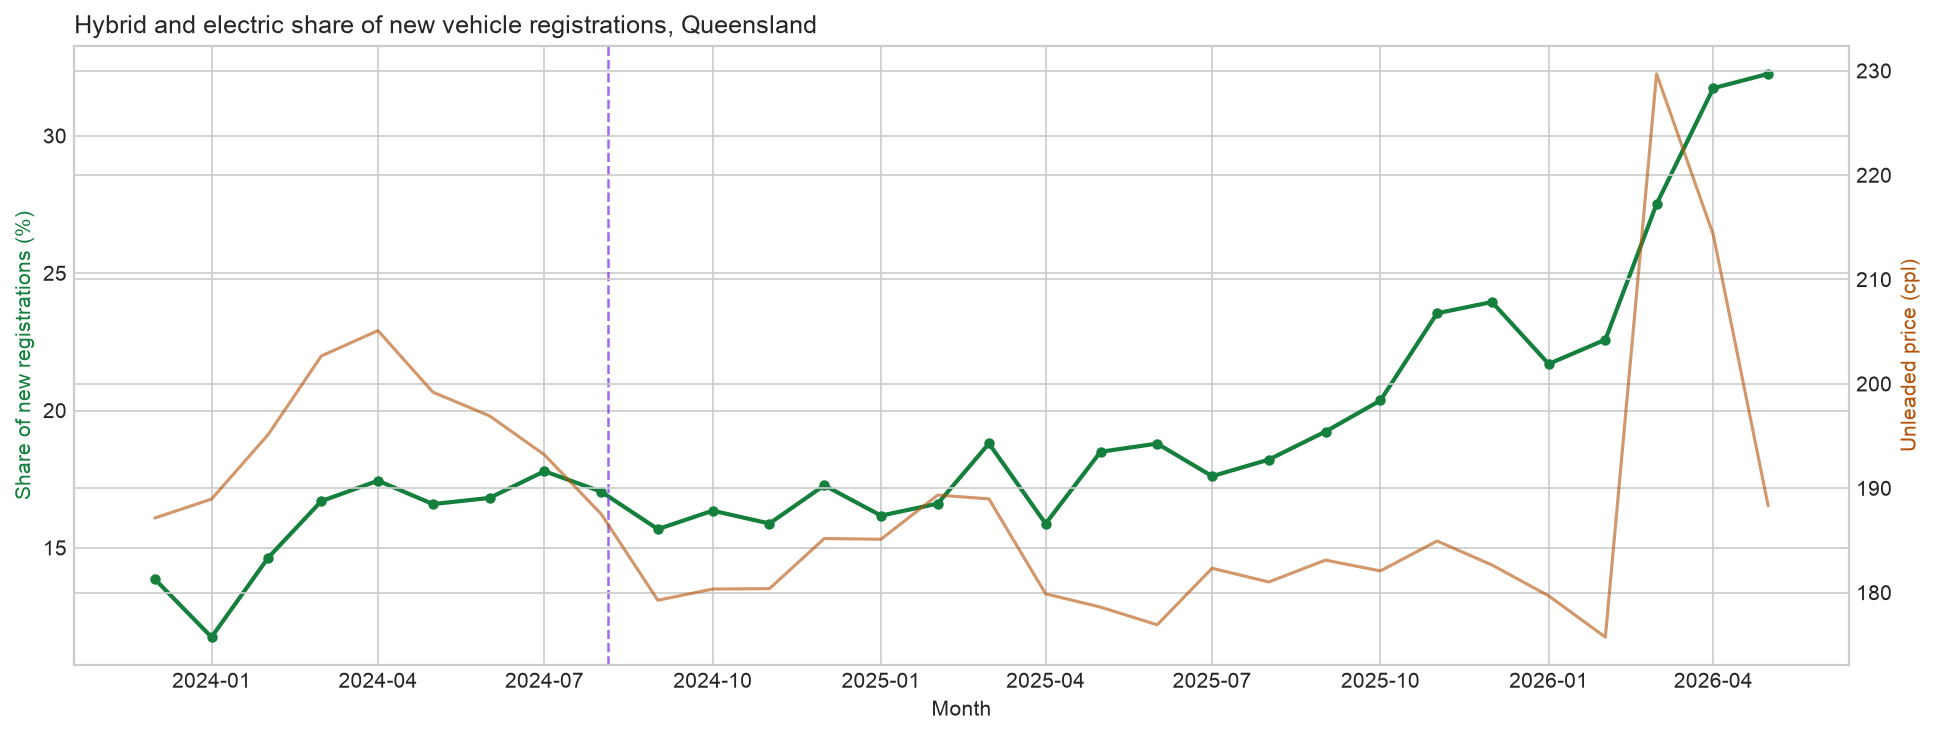

Hybrid/electric share: 13.9% in Dec 2023 -> 32.3% in May 2026
Correlation with the fuel price, levels:               +0.34
Correlation with the fuel price, month-to-month change: +0.42


In [32]:
# The composition question -- the one fuel prices plausibly do move.
# A high running cost makes an efficient car more attractive at the point of purchase.
electrified = share['Hybrid'] + share['Electric']
corr_levels_alt = electrified.corr(analysis['ulp_cpl'])
corr_chg_alt = electrified.diff().corr(analysis['ulp_cpl'].diff())

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(electrified.index, electrified, color=C['cars'], marker='o', ms=4, lw=2)
ax.set_ylabel('Share of new registrations (%)', color=C['cars'])
ax.set_title('Hybrid and electric share of new vehicle registrations, Queensland', loc='left')
ax.set_xlabel('Month')
ax.axvline(FARE_TRIAL, **POLICY_KW)
ax2 = ax.twinx()
ax2.plot(analysis.index, analysis['ulp_cpl'], color=C['fuel'], lw=1.5, alpha=0.6)
ax2.set_ylabel('Unleaded price (cpl)', color=C['fuel'])
plt.tight_layout()
plt.show()

print(f'Hybrid/electric share: {electrified.iloc[0]:.1f}% in {electrified.index[0]:%b %Y} '
      f'-> {electrified.iloc[-1]:.1f}% in {electrified.index[-1]:%b %Y}')
print(f'Correlation with the fuel price, levels:               {corr_levels_alt:+.2f}')
print(f'Correlation with the fuel price, month-to-month change: {corr_chg_alt:+.2f}')

**Do not read the second number as evidence.** The share rises in almost every month of the
window — it is close to a straight line. Two series that each drift steadily will correlate
with each other and with almost anything else, so both figures are picking up shared drift
rather than a response to fuel. Differencing once is not enough to remove a trend this smooth:
the change correlation comes out at +0.42, higher than the levels correlation of +0.34, which is
the opposite of what a genuine month-to-month response would look like.

What would separate the two explanations is a *fuel price shock* — a sharp, isolated move with
no matching move in incomes or model availability — and the later 2026 spike is not clean
enough for that, because EV incentives, model launches and the Nov 2025 federal efficiency
standard all change over the same months. We report the pattern and stop short of attributing
it.

**4.5 RQ5 — all four together.** Fitting all four at once on 30 monthly observations would
produce coefficients that look precise and mean very little. What is defensible is one
descriptive regression per outcome, reported with uncertainty and its obvious weaknesses.

In [33]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

# Population belongs in the frame, so the fare coefficient can be read per
# resident rather than absorbing a rising denominator.
analysis['population'] = pop_monthly
analysis['trips_per_resident'] = trips_per_resident
# Year-on-year change in trips per resident. The twelve-month lag has to be taken
# before the transition month is dropped, or the lag would reach back over a gap.
analysis['yoy_rate'] = analysis['trips_per_resident'].pct_change(12, fill_method=None) * 100

reg_data = analysis.dropna(subset=['fare_50c'])

# Three specifications, every outcome per resident. Errors are HAC (Newey-West,
# 3 lags), the honest choice for monthly data whose residuals are serially
# correlated. The year-on-year column cannot carry the fare -- a frame reaching
# back twelve months survives only in months that are already post-policy, where
# the dummy is constant -- so it is there to test whether fuel explains growth
# that population and the fare between them have not.
SPECS = [
    ('Patronage per resident',      'trips_per_resident',     'Trips per person',
     ['fare_50c', 'ulp_cpl']),
    ('Patronage per resident, YoY', 'yoy_rate',               'Change vs year earlier (%)',
     ['ulp_cpl']),
    ('Registrations per 1,000',     'registrations_per_1000', 'Per 1,000 residents',
     ['fare_50c', 'ulp_cpl']),
]


def fit(outcome, terms):
    y = reg_data[outcome]
    X = sm.add_constant(reg_data[terms])
    ok = X.notna().all(axis=1) & y.notna()
    return sm.OLS(y[ok], X[ok]).fit(cov_type='HAC', cov_kwds={'maxlags': 3})


def stars(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''


fitted = {name: fit(outcome, terms) for name, outcome, _, terms in SPECS}

# Coefficient with its standard error in brackets beside it and significance
# stars on the coefficient -- the layout a published table uses, rather than
# three separate printouts the reader has to hold in their head at once.
ROWS = [('50c fare (0/1)', 'fare_50c'),
        ('Fuel price (cpl)', 'ulp_cpl'),
        ('Constant', 'const')]
body = {}
for name, model in fitted.items():
    body[name] = {
        label: (f'{model.params[key]:.3f}{stars(model.pvalues[key])}'
                f' ({model.bse[key]:.3f})') if key in model.params.index else ''
        for label, key in ROWS
    }

print('OLS. Counts per resident, one specification per column.')
print('HAC (Newey-West, 3 lags) standard errors in brackets, after each coefficient.')
print()
print(pd.DataFrame(body).loc[[r[0] for r in ROWS]].to_string())
print()

foot = {}
for name, outcome, units, terms in SPECS:
    m = fitted[name]
    try:
        fstat, fp = f'{m.fvalue:.2f}', f'{m.f_pvalue:.4f}'
    except Exception:
        fstat, fp = 'n/a', 'n/a'
    foot[name] = {
        'Dependent variable': units,
        'Observations': f'{int(m.nobs)}',
        'R-squared': f'{m.rsquared:.3f}',
        'Adjusted R-squared': f'{m.rsquared_adj:.3f}',
        'F-statistic': fstat,
        'Prob (F-statistic)': fp,
        'Durbin-Watson': f'{durbin_watson(m.resid):.3f}',
        'HAC lags': '3',
    }
print(pd.DataFrame(foot).to_string())
print()
print('Significance: *** p<0.01, ** p<0.05, * p<0.1.')
print('The fare row is blank in the year-on-year column because the dummy is')
print('constant there and cannot be estimated.')
n_levels = int(fitted['Patronage per resident'].nobs)
n_yoy = int(fitted['Patronage per resident, YoY'].nobs)
print(f'The two levels models use {n_levels} months -- August 2024 is dropped because')
print(f'the fare changed part-way through it. The year-on-year model uses {n_yoy},')
print('having spent twelve of them on the lag.')

OLS. Counts per resident, one specification per column.
HAC (Newey-West, 3 lags) standard errors in brackets, after each coefficient.

                 Patronage per resident Patronage per resident, YoY Registrations per 1,000
50c fare (0/1)         0.638*** (0.117)                                       0.129 (0.218)
Fuel price (cpl)       0.012*** (0.003)             0.375** (0.167)           0.006 (0.006)
Constant                  0.036 (0.588)           -58.398* (32.031)        5.161*** (1.250)

                   Patronage per resident Patronage per resident, YoY Registrations per 1,000
Dependent variable       Trips per person  Change vs year earlier (%)     Per 1,000 residents
Observations                           29                          18                      29
R-squared                           0.485                       0.218                   0.034
Adjusted R-squared                  0.445                       0.169                  -0.040
F-statistic               

**What the population column does — and why it does it.** It changes the answer, and the
honest reading is more interesting than the convenient one. Counted per resident the fare
coefficient is 0.64 extra trips per person per month, significant at p < 0.001. On raw levels
the same model returns 3.99 million trips without a population control and 1.73 with one, at
which point it is no longer significant (p = 0.17). Those two raw-level numbers come from a
model that is not in the table above, and they are quoted here precisely because dropping it
silently would make the per-resident estimate look more solid than the design supports.

That is **not** because population explains the rise. The year-on-year decomposition above
shows population accounts for only about 1.7 of the 13.8 points. It happens because a fare
step that switches on once and never off is, over a 29-month window with only 8 pre-policy
months, nearly indistinguishable from a steady upward population trend. The two compete for
the same variation and the regression cannot tell them apart. That is a limitation of the
design, not a null result.

The per-resident model avoids the problem by dividing population out *before* fitting, rather
than asking the regression to separate two collinear series, and that is the coefficient to
quote. The levels model is not a second opinion on it — it is the same data with an
identification problem, which is why it has been taken out of the table.

**One number in the table needs a warning.** In the year-on-year column the fuel price carries
a positive coefficient on trips per resident (0.375, significant at 5%), which on its face says
that dearer petrol puts people on trains. Treat it as the confound it is. The 2026 fuel spike
falls in the same months as the highest patronage readings in the window, so the two move
together at the end of the series; with 18 observations and no way to separate them, the
coefficient absorbs the coincidence. The caution runs the other way too: because the fare dummy
is constant in that frame, the column cannot say anything about the fare. It is reported for
completeness, not as a rival explanation.

Do not read those p-values as causal evidence all the same, for three reasons. The fare
variable is a step rather than an experiment: it switches on once and never off, so it is
nearly collinear with time itself, and its coefficient absorbs everything else that changed
after August 2024 — service levels, post-pandemic recovery, the fuel spike. Population is the
one of these we can put in the model, which is why the population adjustment matters more than
its size suggests: it is the only competing explanation we can rule out with the data. There is
also no control group, since everything here is Queensland, and without a comparable state that
did not cut fares the policy cannot be separated from the trend. And lagged effects are
invisible: travel habits take months to change, and a car purchase responds over a much longer
horizon than this window covers.

---

**Step 5 — storytelling with data.**

**What we can say.** The fare moved patronage, and most of it stuck — and it is not population.
Trips rose on every mode after August 2024, in year-on-year terms and not merely as a seasonal
pattern. The rise is not a growing state being counted twice: Queensland's population added
about 1.7% a year, which accounts for about 1.7 of the 13.8 percentage points — roughly
one-eighth — leaving **11.8% per year per resident** for the fare to explain. The per-resident
regression puts the fare at 0.64 extra trips per resident per month (p < 0.001).

One caveat has to travel with that number. Population and the fare cannot be separated in a raw
levels regression, because over 29 months with only 8 pre-policy months a step that switches on
once is collinear with a steady upward trend — put both in and the fare coefficient halves and
loses significance. That is an identification failure, not evidence the fare did nothing. It is
why the per-resident specification, which divides population out before fitting, is the one to
quote rather than the levels model.

The persistence is uneven, and worth stating honestly rather than smoothing over. These are
per-resident figures. Bus (10.3% → 11.9%) held its gain into the second policy year and Ferry
(25.2% → 18.3%) kept most of its own, while Citytrain (18.2% → 4.6%) and Tram (24.0% → 7.9%)
fell back sharply — which looks less like a durable shift in commuting than a novelty response
that faded.

The two prices also act on different things. The fare is a policy step that changes how people
travel this week; petrol is a volatile cost that changes slowly what people drive and buy. Over
this window the fuel price shows no detectable relationship with registration counts, but it
does line up with a steady shift toward hybrid and electric cars, which is the channel where a
running cost plausibly matters. Car ownership did not visibly respond to the fare at all: new
registrations show no break at August 2024, which is consistent with the interpretation in the
broader project that the extra trips look largely discretionary rather than car commutes
replaced.

**What we cannot say.**

| Claim we would like to make | Why we cannot |
|---|---|
| "The fare cut caused a X% rise in patronage" | Only 8 pre-policy months (Dec 2023 – Jul 2024), so only the first policy year has a pre-policy year-on-year baseline; and no control state |
| "Higher petrol prices reduce car sales" | Effect not detectable at n≈23; confounded with the 2026 spike |
| "Queensland's fleet is going electric because of fuel prices" | The trend starts before the window and is nationwide |
| "The policy reduced emissions by Y tonnes" | Needs a driving measure (fuel sales, traffic counts), not ownership |

**What would strengthen this.** A longer patronage series reaching back before 2023 would give
the year-on-year comparison a real pre-policy baseline instead of one observation. A control
state — Victoria or New South Wales fares — would enable a difference-in-differences design,
and this is the single biggest gap. A direct driving measure, such as the monthly petrol sales
by state that the wider project already uses, would measure driving rather than only ownership.
And the used-vehicle transfers contained in the registration source, which we did not use,
would separate new-car demand from fleet churn.

**Known limitations of the data itself.**

| Issue | Effect on the analysis |
|---|---|
| Patronage is Southeast Queensland; fuel, registrations and population are all Queensland | Two mismatches. SEQ is roughly 70% of the state for fuel and registrations — and because SEQ grows faster than the state as a whole, dividing SEQ trips by *Queensland* population **overstates** trips per resident. The population-adjusted figure is therefore an upper bound, not a conservative one |
| Queensland population is quarterly, and the ABS file ends Mar 2026 | Interpolated to monthly, and the last two months (~0.2%) are extrapolated at the last observed growth rate. Small enough not to move the conclusion, but it is an assumption |
| Population is the whole state, so it cannot adjust for the age structure of the SEQ catchment | A growing state adds residents of all ages; if growth skews to areas or ages that travel less, the true per-resident effect is larger than measured, not smaller |
| Petrol prices are "changes only", forward-filled to daily | Early months average over fewer stations (1,491 in Sep 2023 vs ~1,590 by late 2025) |
| Station-level reporting frequency varies | Monthly means lean toward frequently-reporting sites |
| BITRE stock has three annual observations | Context only; cannot be modelled |
| Patronage counts trips, not people | One person can contribute many trips |
| Cyclone Alfred (Mar 2025) disrupted SEQ services | Creates a one-off dip that must be flagged, not modelled |